# **WIA 1007 Introduction to Data Science Group Assignment**

# 1.0 Project Design

# 2.0 Data Collection

In [ ]:
#Load dataset from Google Drive
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Credit Card Customers.csv')

Mounted at /content/drive


# 3.0 Data Preprocessing

## 3.1 Initial Data Exploration

Here are the description of the column names:
1.	CLIENTNUM: Unique identifier for each customer.
2.	Attrition_Flag: Indicates if the customer is an existing customer or if they have churned (e.g., "Existing Customer" or "Attrited Customer").
3.	Customer_Age: The age of the customer.
4.	Gender: The gender of the customer ("M" for Male, "F" for Female).
5.	Dependent_count: Number of dependents associated with the customer.
6.	Education_Level: The education level of the customer (e.g., "High School," "Graduate").
7.	Marital_Status: The marital status of the customer (e.g., "Single," "Married").
8.	Income_Category: The income range of the customer (e.g., "$60K - $80K," "Less than $40K").
9.	Card_Category: The category of credit card held by the customer (e.g., "Blue").
10.	Months_on_book: The total number of months the customer has been associated with the bank.
11.	Total_Relationship_Count: The total number of products held by the customer with the bank.
12.	Months_Inactive_12_mon: The number of months in the past year the customer was inactive.
13.	Contacts_Count_12_mon: The number of contacts made by the customer with the bank in the last year.
14.	Credit_Limit: The credit limit assigned to the customer.
15.	Total_Revolving_Bal: The total revolving balance on the customer’s account.
16.	Avg_Open_To_Buy: The average open-to-buy credit limit available.
17.	Total_Amt_Chng_Q4_Q1: The change in the total transaction amount from Q4 to Q1.
18.	Total_Trans_Amt: The total transaction amount in the last 12 months.
19.	Total_Trans_Ct: The total transaction count in the last 12 months.
20.	Total_Ct_Chng_Q4_Q1: The change in the transaction count from Q4 to Q1.
21.	Avg_Utilization_Ratio: The average card utilization ratio.
22.	Naive_Bayes_Classifier_1: A probabilistic classifier (output value 1 from the Naive Bayes model).
23.	Naive_Bayes_Classifier_2: A probabilistic classifier (output value 2 from the Naive Bayes model).


In [ ]:
#Show the first 5 rows of the dataset
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 3.2 Get to know the information of the dataset

In [ ]:
#Check the info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [ ]:
#Determine Data Types
df.dtypes

,0
CLIENTNUM,int64
Attrition_Flag,object
Customer_Age,int64
Gender,object
Dependent_count,int64
Education_Level,object
Marital_Status,object
Income_Category,object
Card_Category,object
Months_on_book,int64


In [ ]:
#Replace "Unknown" with NaN
df.replace("Unknown", pd.NA, inplace=True)
#Display sum of NaN
df.isna().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,1519
Marital_Status,749
Income_Category,1112
Card_Category,0
Months_on_book,0


In [ ]:
#Detect outliers
def detect_outliers_iqr(column):
  Q1 = column.quantile(0.25)
  Q3 = column.quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = column[(column < lower_bound) | (column > upper_bound)]
  return outliers
outliers_dict = {column: detect_outliers_iqr(df[column]) for column in df.select_dtypes(include=[np.number]).columns}
for column, outliers in outliers_dict.items():
    print(f"Outliers in column '{column}':\n{outliers}\n")

Outliers in column 'CLIENTNUM':
Series([], Name: CLIENTNUM, dtype: int64)

Outliers in column 'Customer_Age':
251    73
254    70
Name: Customer_Age, dtype: int64

Outliers in column 'Dependent_count':
Series([], Name: Dependent_count, dtype: int64)

Outliers in column 'Months_on_book':
11       54
18       56
27       56
39       56
52       54
         ..
10054    15
10062    17
10069    14
10107    54
10114    15
Name: Months_on_book, Length: 386, dtype: int64

Outliers in column 'Total_Relationship_Count':
Series([], Name: Total_Relationship_Count, dtype: int64)

Outliers in column 'Months_Inactive_12_mon':
12       6
29       0
31       5
108      0
118      6
        ..
9964     5
10028    5
10035    6
10049    5
10066    6
Name: Months_Inactive_12_mon, Length: 331, dtype: int64

Outliers in column 'Contacts_Count_12_mon':
2        0
4        0
8        0
12       0
20       0
        ..
10101    5
10106    5
10109    5
10114    5
10120    0
Name: Contacts_Count_12_mon, Length: 6

In [ ]:
#Get Data Completeness percentage
completeness = df.notna().mean() * 100
print("Data Completeness (%):\n", completeness)

Data Completeness (%):
 CLIENTNUM                                                                                                                             100.000000
Attrition_Flag                                                                                                                        100.000000
Customer_Age                                                                                                                          100.000000
Gender                                                                                                                                100.000000
Dependent_count                                                                                                                       100.000000
Education_Level                                                                                                                        85.000494
Marital_Status                                                                                            

## 3.3 Data Cleaning

In [ ]:
#Drop the rows with more than 2 missing values
df_full = df.dropna(thresh=2)
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [ ]:
# Create a copy of the DataFrame to avoid modifying the original
df_full2 = df_full.copy()

# Impute missing values with the mode for each column
for column in df_full2.columns:
    mode_value = df_full2[column].mode()[0]
    df_full2[column].fillna(mode_value, inplace=True)

# Display the DataFrame after imputation
print("DataFrame after imputing missing values with mode:\n", df_full2)


DataFrame after imputing missing values with mode:
        CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0      768805383  Existing Customer            45      M                3   
1      818770008  Existing Customer            49      F                5   
2      713982108  Existing Customer            51      M                3   
3      769911858  Existing Customer            40      F                4   
4      709106358  Existing Customer            40      M                3   
...          ...                ...           ...    ...              ...   
10122  772366833  Existing Customer            50      M                2   
10123  710638233  Attrited Customer            41      M                2   
10124  716506083  Attrited Customer            44      F                1   
10125  717406983  Attrited Customer            30      M                2   
10126  714337233  Attrited Customer            43      F                2   

      Education_Level M

<ipython-input-9-2f8effba0688>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_full2[column].fillna(mode_value, inplace=True)
<ipython-input-9-2f8effba0688>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [ ]:
#All the missing values are imputed
df_full2.isna().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


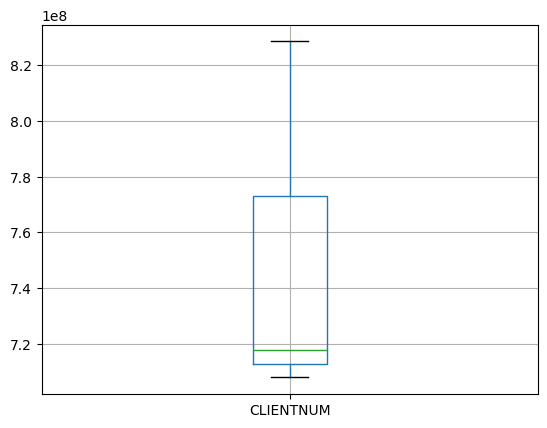

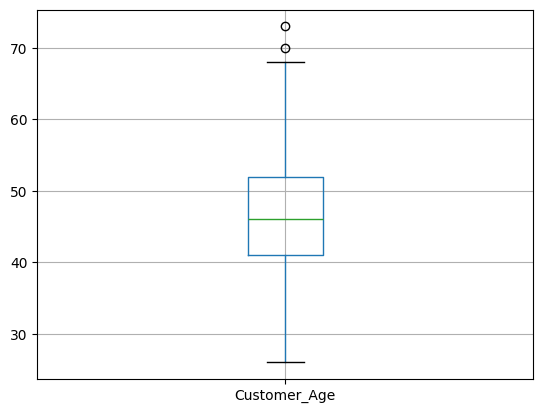

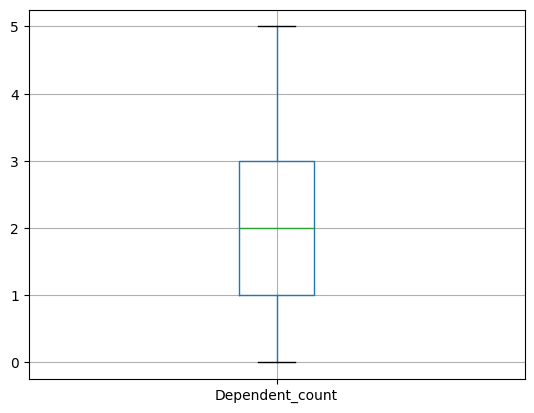

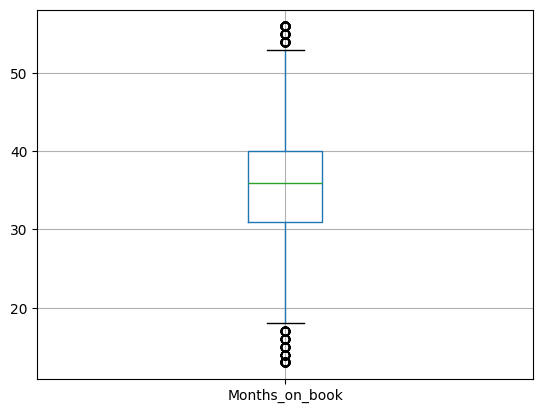

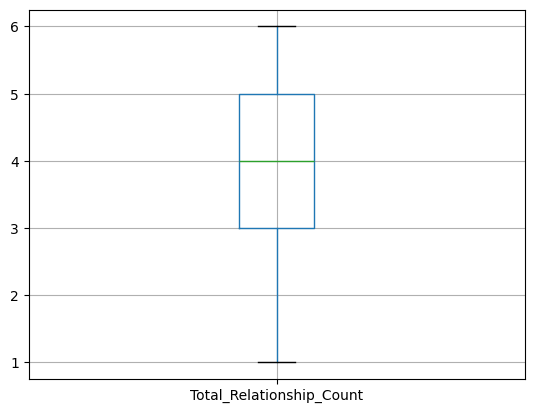

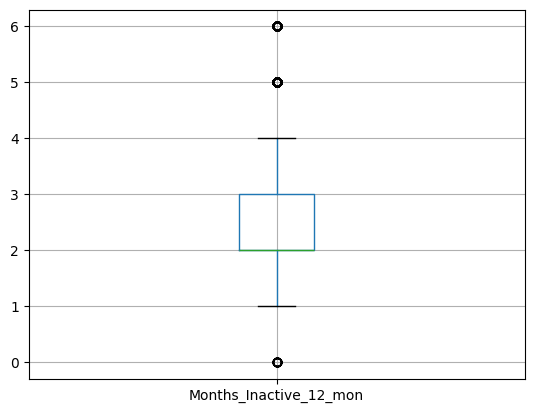

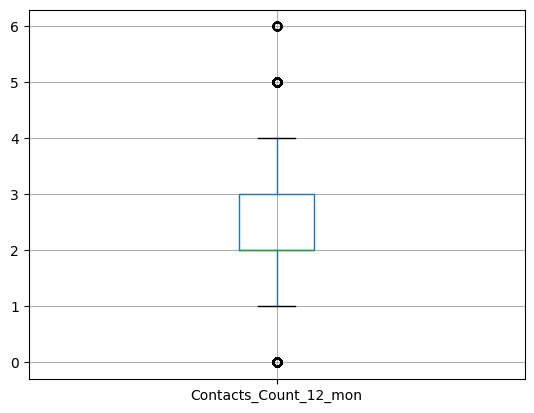

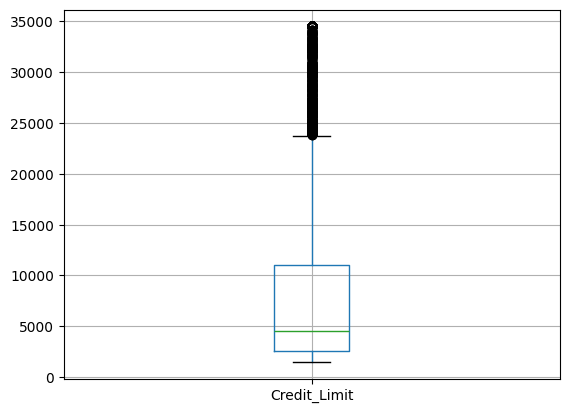

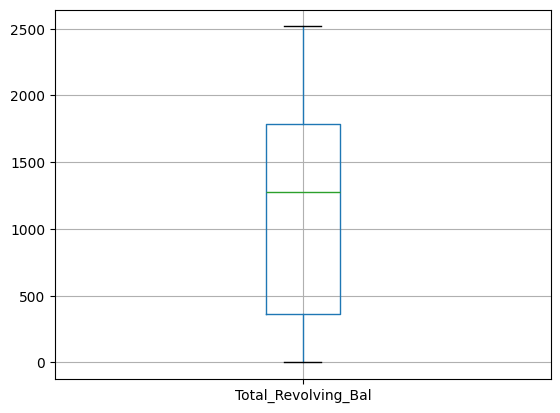

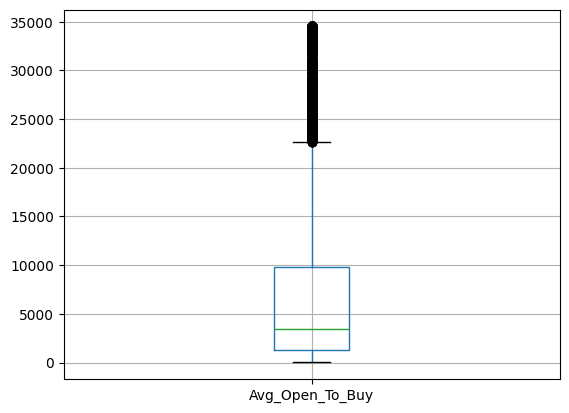

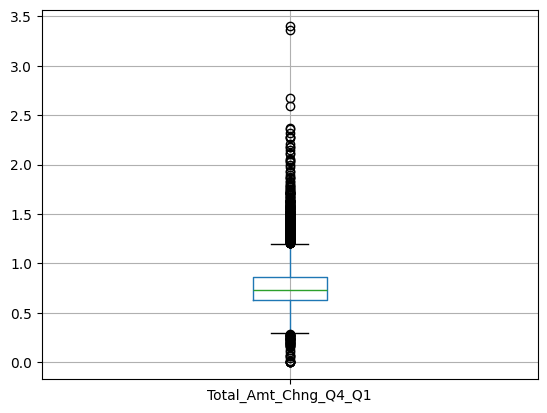

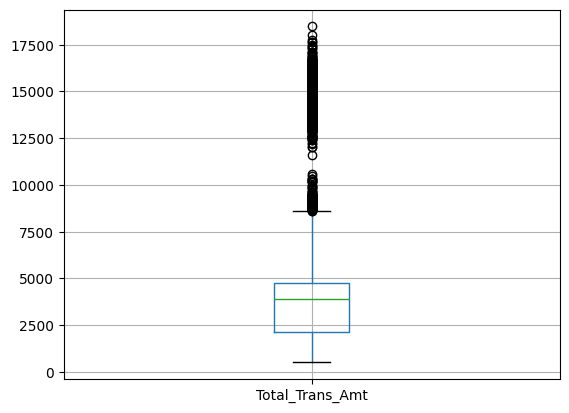

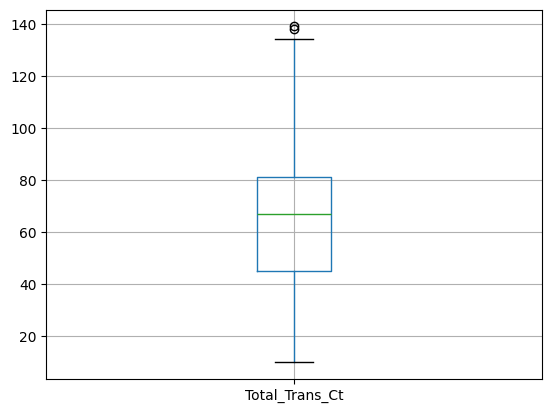

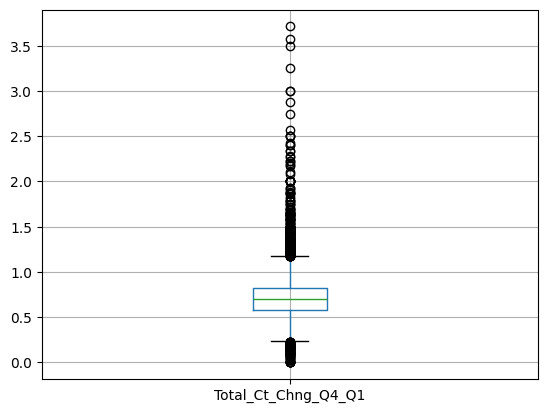

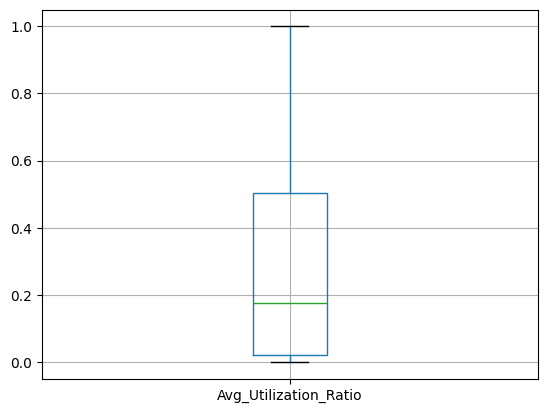

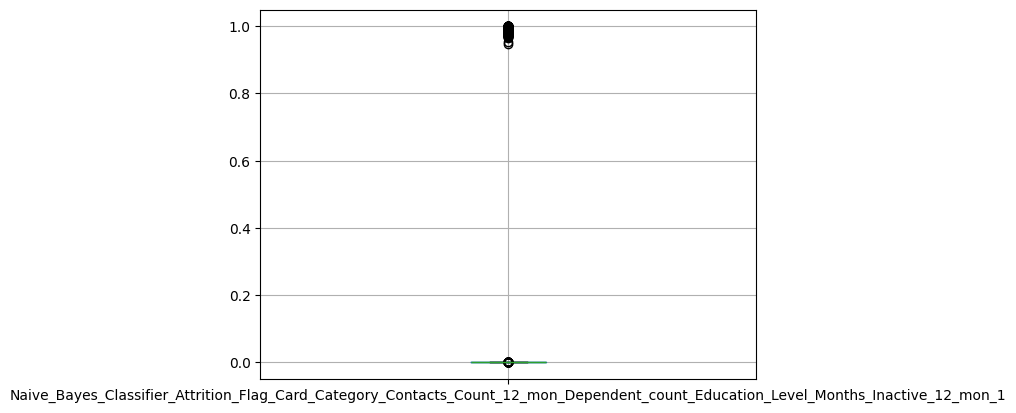

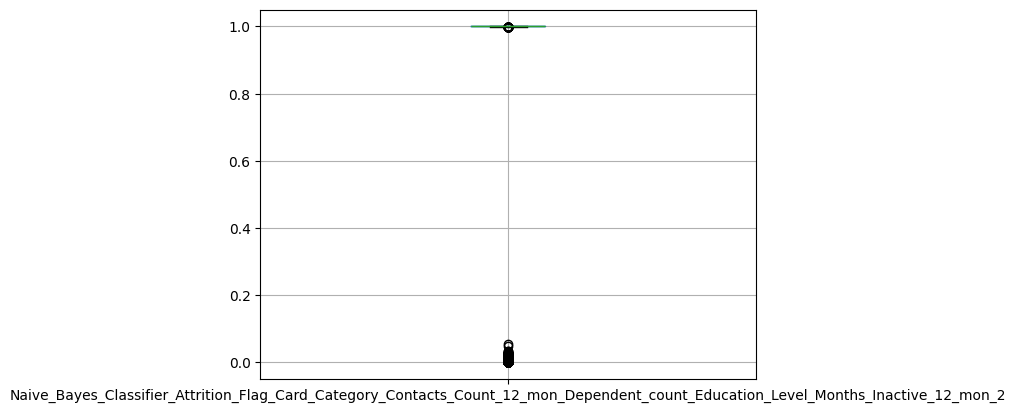

In [ ]:
#Detect outliers by boxplot
import matplotlib.pyplot as plt
import seaborn as sns
df_numeric = df_full2.select_dtypes(include=np.number)
for column in df_numeric.columns:
    df_full2.boxplot(column=column)
    plt.show()

In [ ]:
#Remove outliers
numerical_df = df_full2.select_dtypes(include=[np.number])
def remove_outliers_iqr(df_full2):
  Q1 = df_full2.quantile(0.25)
  Q3 = df_full2.quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  return df_full2[~((df_full2 < lower_bound) | (df_full2 > upper_bound)).any(axis=1)]
df_no_outliers = remove_outliers_iqr(numerical_df)
print("DataFrame without outliers:\n", df_no_outliers)

DataFrame without outliers:
       CLIENTNUM  Customer_Age  Dependent_count  Months_on_book  \
10    708790833            42                5              31   
14    712396908            57                2              48   
19    709327383            45                2              37   
23    811604133            47                4              36   
24    789124683            54                2              42   
...         ...           ...              ...             ...   
9117  711339258            49                3              36   
9122  771674958            45                2              33   
9130  720819858            47                4              27   
9133  709883883            46                4              34   
9139  713236458            55                4              48   

      Total_Relationship_Count  Months_Inactive_12_mon  Contacts_Count_12_mon  \
10                           5                       3                      2   
14              

In [ ]:
#Merge the numeric column dataset(no outliers) with the full column dataset(no missing value)
df_no_outliers.index = df_full2.index[:len(df_no_outliers)]
df_cleaned = df_full2.loc[df_no_outliers.index]
print("Merged DataFrame (original columns retained):\n", df_cleaned)

Merged DataFrame (original columns retained):
       CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0     768805383  Existing Customer            45      M                3   
1     818770008  Existing Customer            49      F                5   
2     713982108  Existing Customer            51      M                3   
3     769911858  Existing Customer            40      F                4   
4     709106358  Existing Customer            40      M                3   
...         ...                ...           ...    ...              ...   
5665  715625658  Existing Customer            49      F                3   
5666  789599283  Existing Customer            44      F                3   
5667  708960858  Existing Customer            40      M                4   
5668  814840833  Attrited Customer            44      M                4   
5669  772082208  Existing Customer            39      M                1   

     Education_Level Marital_Status Inco

### 3.4 Feature Extraction

In [ ]:
#Drop useless columns
df_cleaned = df_cleaned.drop(columns=['CLIENTNUM', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1','Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'])
df_cleaned.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Married,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


### 3.5 Data Transformation

In [ ]:
# for data preprocessing and transformation
from sklearn.datasets import load_digits
from sklearn import preprocessing
from sklearn.preprocessing import normalize, StandardScaler


def whitespace_remover(dataframe):
    for column in dataframe.columns:
        if dataframe[column].dtype == 'object':
            dataframe[column] = dataframe[column].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Applying whitespace_remover function on the DataFrame
whitespace_remover(df_cleaned)


Generalisation

In [ ]:
# Print the unique values in the 'Education_Level' column
print("The unique values of 'Education_Level' are:", df_cleaned['Education_Level'].unique())

# Generalize the education levels
df_cleaned['Education_Level'].replace(
    to_replace=['Graduate', 'Post-Graduate', 'Doctorate'],
    value='Graduate',
    inplace=True
)
df_cleaned['Education_Level'].replace(
    to_replace=['High School', 'College'],
    value='High School',
    inplace=True
)


# Print the unique values after generalization
print("The unique values of 'Education_Level' after generalization:", df_cleaned['Education_Level'].unique())

The unique values of 'Education_Level' are: ['High School' 'Graduate' 'Uneducated' 'College' 'Post-Graduate'
 'Doctorate']
The unique values of 'Education_Level' after generalization: ['High School' 'Graduate' 'Uneducated']


<ipython-input-16-943b68981a37>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['Education_Level'].replace(


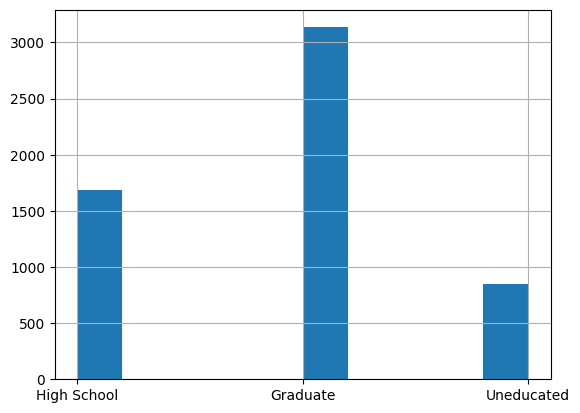

In [ ]:
df_cleaned['Education_Level'].hist()
plt.show()

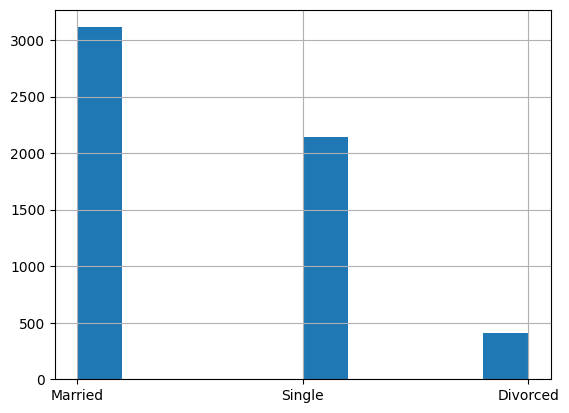

In [ ]:
df_cleaned['Marital_Status'].hist()
plt.show()

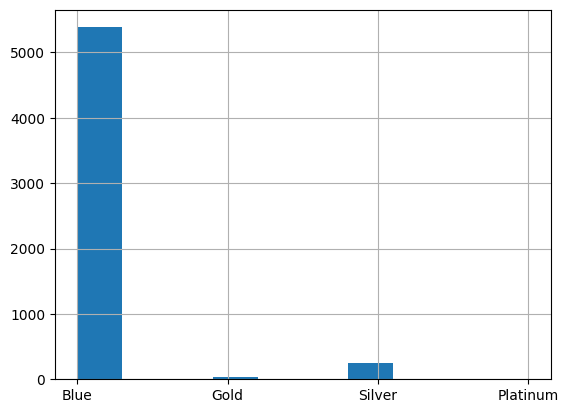

In [ ]:
df_cleaned['Card_Category'].hist()
plt.show()

In [ ]:
print(sum(df_cleaned['Card_Category']=="Platinum"))

3


In [ ]:
df_cleaned.drop(df_cleaned[df_cleaned['Card_Category']== 'Platinum'].index, inplace=True)

print("final unique values for 'Card_Category' : ", df_cleaned['Card_Category'].unique())
print(df_cleaned.shape)

final unique values for 'Card_Category' :  ['Blue' 'Gold' 'Silver']
(5667, 20)


In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5667 entries, 0 to 5669
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            5667 non-null   object 
 1   Customer_Age              5667 non-null   int64  
 2   Gender                    5667 non-null   object 
 3   Dependent_count           5667 non-null   int64  
 4   Education_Level           5667 non-null   object 
 5   Marital_Status            5667 non-null   object 
 6   Income_Category           5667 non-null   object 
 7   Card_Category             5667 non-null   object 
 8   Months_on_book            5667 non-null   int64  
 9   Total_Relationship_Count  5667 non-null   int64  
 10  Months_Inactive_12_mon    5667 non-null   int64  
 11  Contacts_Count_12_mon     5667 non-null   int64  
 12  Credit_Limit              5667 non-null   float64
 13  Total_Revolving_Bal       5667 non-null   int64  
 14  Avg_Open_To_B

Normalization

array([[<Axes: title={'center': 'Customer_Age'}>,
        <Axes: title={'center': 'Dependent_count'}>,
        <Axes: title={'center': 'Months_on_book'}>,
        <Axes: title={'center': 'Total_Relationship_Count'}>],
       [<Axes: title={'center': 'Months_Inactive_12_mon'}>,
        <Axes: title={'center': 'Contacts_Count_12_mon'}>,
        <Axes: title={'center': 'Credit_Limit'}>,
        <Axes: title={'center': 'Total_Revolving_Bal'}>],
       [<Axes: title={'center': 'Avg_Open_To_Buy'}>,
        <Axes: title={'center': 'Total_Amt_Chng_Q4_Q1'}>,
        <Axes: title={'center': 'Total_Trans_Amt'}>,
        <Axes: title={'center': 'Total_Trans_Ct'}>],
       [<Axes: title={'center': 'Total_Ct_Chng_Q4_Q1'}>,
        <Axes: title={'center': 'Avg_Utilization_Ratio'}>, <Axes: >,
        <Axes: >]], dtype=object)

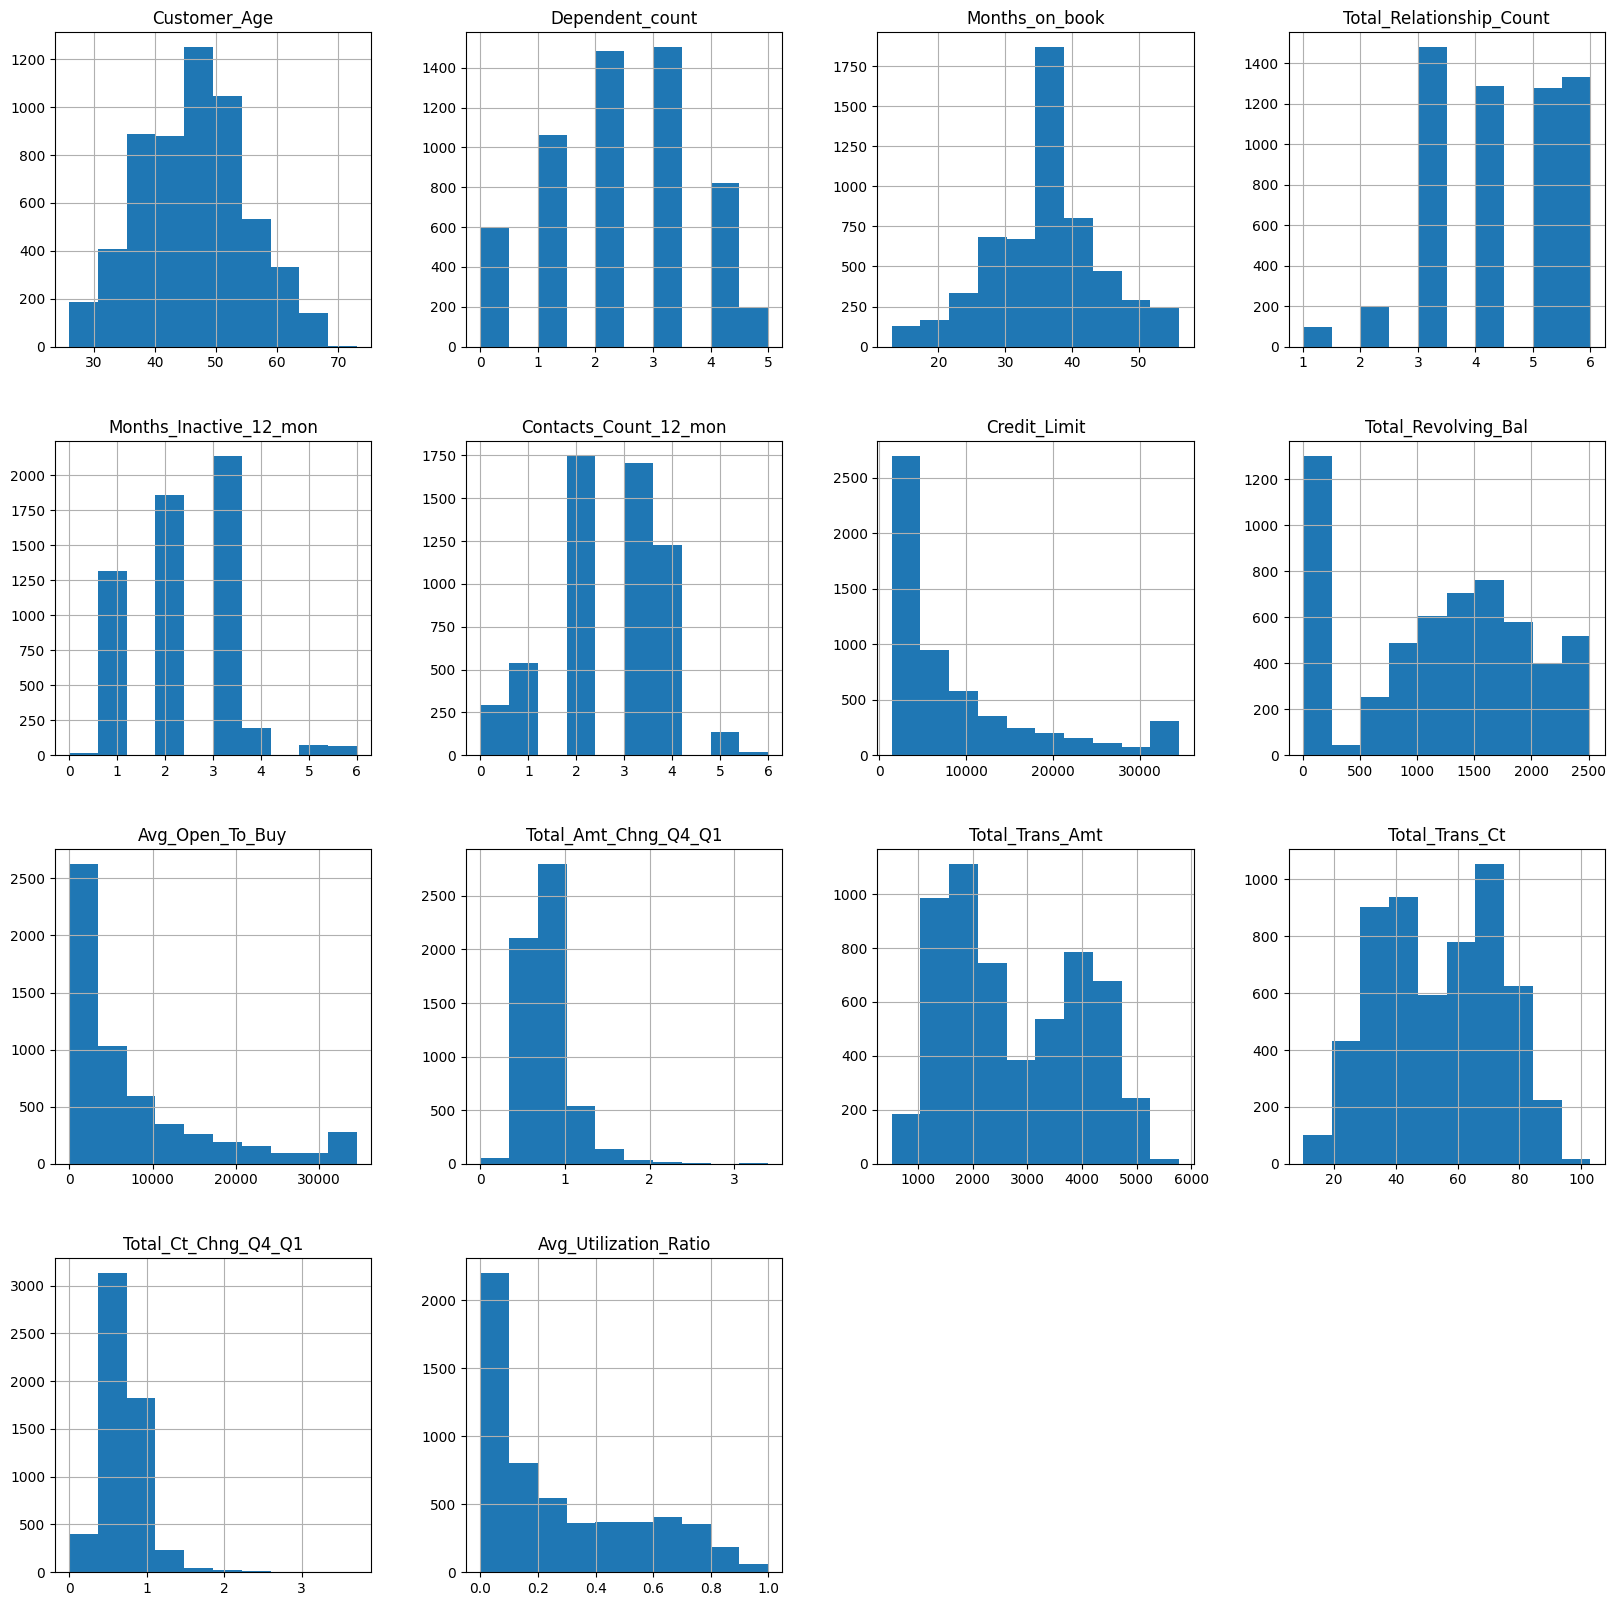

In [ ]:
#Histogram before normalization
df_cleaned.hist(figsize=(20,20))

In [ ]:
#Min max normalization
from sklearn import preprocessing
m=preprocessing.MinMaxScaler(feature_range=(0, 1))
# apply normalization techniques
df_cleaned_norm_min_max = df_cleaned.copy()
df_cleaned_norm_min_max[['Credit_Limit','Total_Revolving_Bal','Total_Trans_Amt','Customer_Age','Dependent_count','Months_on_book','Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1','Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon']]=m.fit_transform(df_cleaned_norm_min_max[['Credit_Limit','Total_Revolving_Bal','Total_Trans_Amt','Customer_Age','Dependent_count','Months_on_book','Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1','Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon']])
#After min-max normalization
df_cleaned_norm_min_max.head()


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,0.404255,M,0.6,High School,Married,$60K - $80K,Blue,0.604651,0.8,0.166667,0.500000,0.340190,0.308701,0.345116,0.392994,0.120235,0.344086,0.437534,0.061061
1,Existing Customer,0.489362,F,1.0,Graduate,Single,Less than $40K,Blue,0.720930,1.0,0.166667,0.333333,0.206112,0.343266,0.214093,0.453636,0.148113,0.247312,1.000000,0.105105
2,Existing Customer,0.531915,M,0.6,Graduate,Married,$80K - $120K,Blue,0.534884,0.6,0.166667,0.000000,0.059850,0.000000,0.098948,0.763615,0.261142,0.107527,0.628164,0.000000
3,Existing Customer,0.297872,F,0.8,High School,Married,Less than $40K,Blue,0.488372,0.4,0.666667,0.166667,0.056676,1.000000,0.022977,0.413600,0.125356,0.107527,0.628164,0.760761
4,Existing Customer,0.297872,M,0.6,Uneducated,Married,$60K - $80K,Blue,0.186047,0.8,0.166667,0.000000,0.099091,0.000000,0.136557,0.640271,0.058031,0.193548,0.673129,0.000000


array([[<Axes: title={'center': 'Customer_Age'}>,
        <Axes: title={'center': 'Dependent_count'}>,
        <Axes: title={'center': 'Months_on_book'}>,
        <Axes: title={'center': 'Total_Relationship_Count'}>],
       [<Axes: title={'center': 'Months_Inactive_12_mon'}>,
        <Axes: title={'center': 'Contacts_Count_12_mon'}>,
        <Axes: title={'center': 'Credit_Limit'}>,
        <Axes: title={'center': 'Total_Revolving_Bal'}>],
       [<Axes: title={'center': 'Avg_Open_To_Buy'}>,
        <Axes: title={'center': 'Total_Amt_Chng_Q4_Q1'}>,
        <Axes: title={'center': 'Total_Trans_Amt'}>,
        <Axes: title={'center': 'Total_Trans_Ct'}>],
       [<Axes: title={'center': 'Total_Ct_Chng_Q4_Q1'}>,
        <Axes: title={'center': 'Avg_Utilization_Ratio'}>, <Axes: >,
        <Axes: >]], dtype=object)

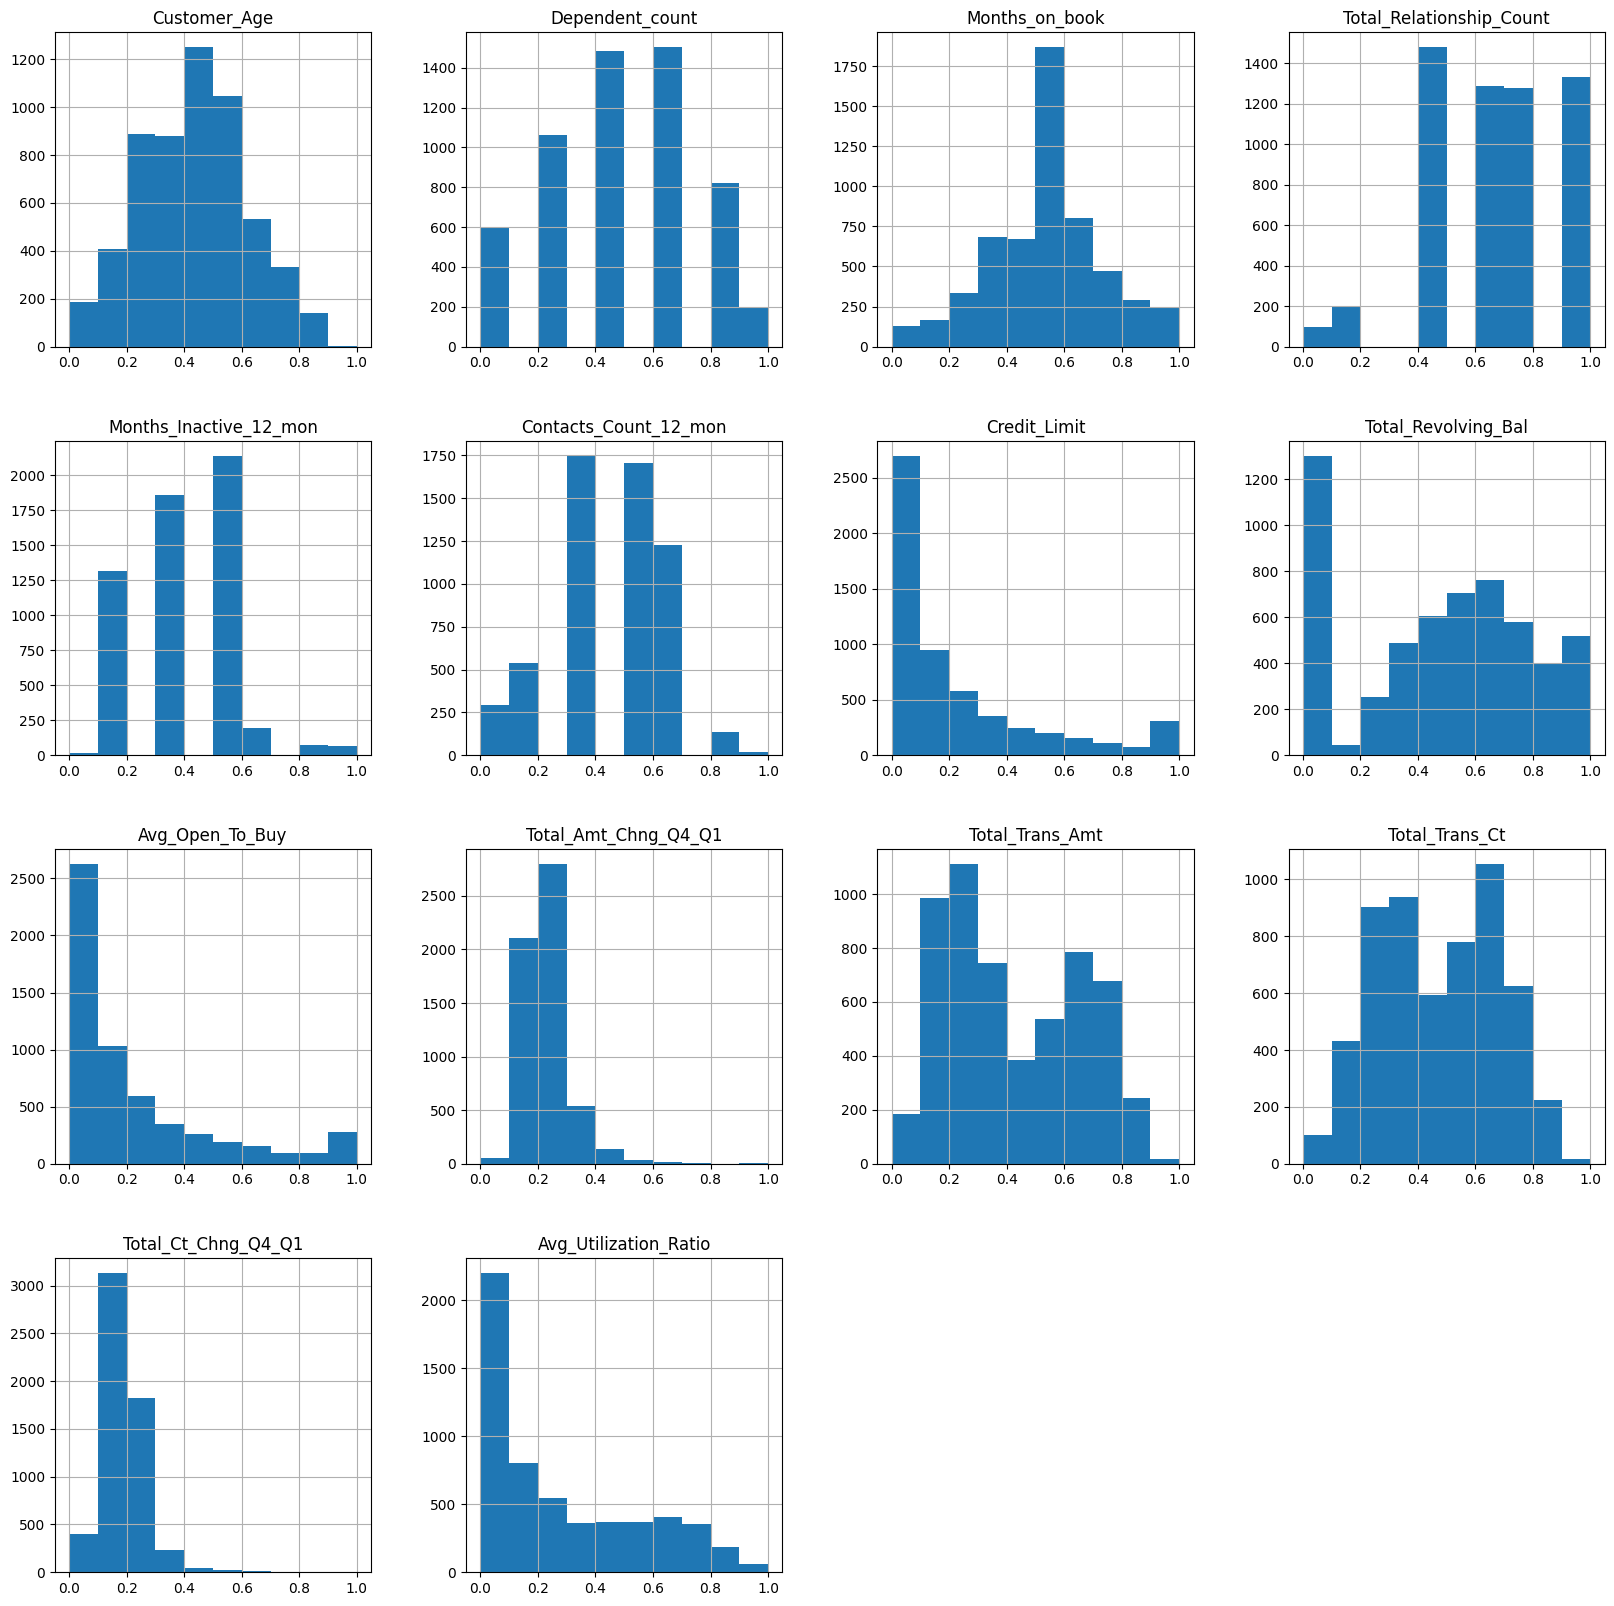

In [ ]:
#Histogram after min max normalization
df_cleaned_norm_min_max.hist(figsize=(20,20))

In [ ]:
#Z-score normalization
m=preprocessing.StandardScaler()
# apply normalization techniques
df_cleaned_norm_std_scaler = df_cleaned.copy()
df_cleaned_norm_std_scaler[['Credit_Limit','Total_Revolving_Bal','Total_Trans_Amt','Customer_Age','Dependent_count','Months_on_book','Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1','Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon']]=m.fit_transform(df_cleaned_norm_std_scaler[['Credit_Limit','Total_Revolving_Bal','Total_Trans_Amt','Customer_Age','Dependent_count','Months_on_book','Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1','Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon']])
#After z-score normalization
df_cleaned_norm_std_scaler.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,-0.158151,M,0.565012,High School,Married,$60K - $80K,Blue,0.357479,0.538996,-1.310134,0.328028,0.430783,-0.518425,0.475773,2.151152,-1.319840,-0.625104,3.280388,-0.780187
1,Existing Customer,0.306825,F,2.097401,Graduate,Single,Less than $40K,Blue,0.948654,1.325222,-1.310134,-0.533788,-0.068739,-0.410116,-0.031508,2.944554,-1.199056,-1.094394,10.742857,-0.619071
2,Existing Customer,0.539313,M,0.565012,Graduate,Married,$80K - $120K,Blue,0.002775,-0.247231,-1.310134,-2.257420,-0.613651,-1.485735,-0.477313,7.000149,-0.709346,-1.772258,5.809554,-1.003551
3,Existing Customer,-0.739371,F,1.331207,High School,Married,Less than $40K,Blue,-0.233695,-1.033457,1.722762,-1.395604,-0.625477,1.647753,-0.771450,2.420755,-1.297655,-1.772258,5.809554,1.779349
4,Existing Customer,-0.739371,M,0.565012,Uneducated,Married,$60K - $80K,Blue,-1.770748,0.538996,-1.310134,-2.257420,-0.467455,-1.485735,-0.331703,5.386385,-1.589345,-1.355111,6.406123,-1.003551


array([[<Axes: title={'center': 'Customer_Age'}>,
        <Axes: title={'center': 'Dependent_count'}>,
        <Axes: title={'center': 'Months_on_book'}>,
        <Axes: title={'center': 'Total_Relationship_Count'}>],
       [<Axes: title={'center': 'Months_Inactive_12_mon'}>,
        <Axes: title={'center': 'Contacts_Count_12_mon'}>,
        <Axes: title={'center': 'Credit_Limit'}>,
        <Axes: title={'center': 'Total_Revolving_Bal'}>],
       [<Axes: title={'center': 'Avg_Open_To_Buy'}>,
        <Axes: title={'center': 'Total_Amt_Chng_Q4_Q1'}>,
        <Axes: title={'center': 'Total_Trans_Amt'}>,
        <Axes: title={'center': 'Total_Trans_Ct'}>],
       [<Axes: title={'center': 'Total_Ct_Chng_Q4_Q1'}>,
        <Axes: title={'center': 'Avg_Utilization_Ratio'}>, <Axes: >,
        <Axes: >]], dtype=object)

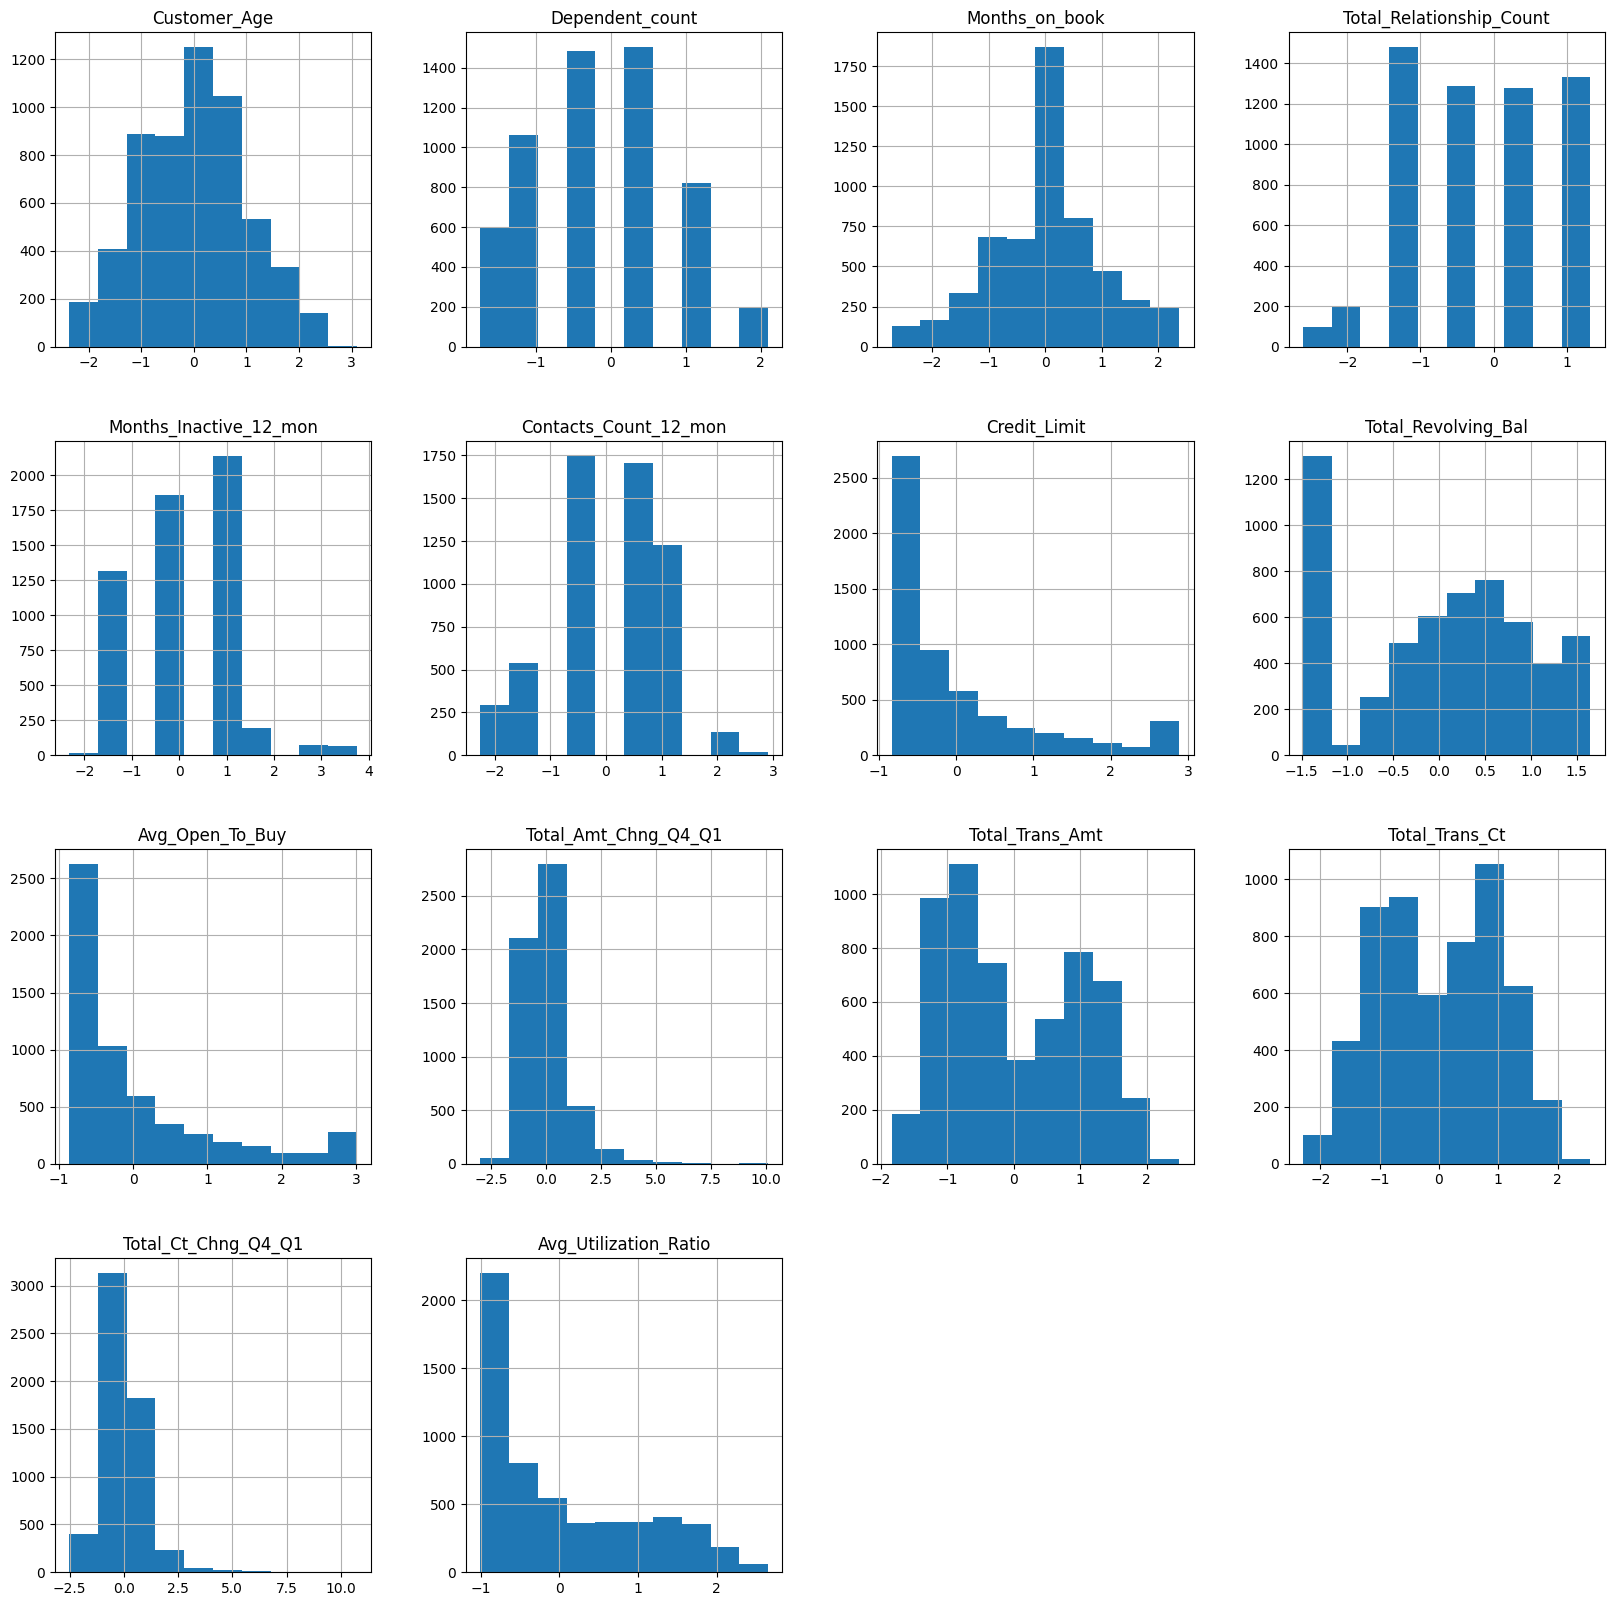

In [ ]:
#Histogram after z-score normalization
df_cleaned_norm_std_scaler.hist(figsize=(20,20))

## 3.6 Data Visualization

In [ ]:
#from google.colab import files

# Save the dataframe to a CSV file
#df_cleaned_norm_std_scaler.to_csv('Credit Card Customers_cleaned.csv', index=False)

# Download the file
#files.download('Credit Card Customers_cleaned.csv')

Creating bar plots for the count of each unique balue in each features

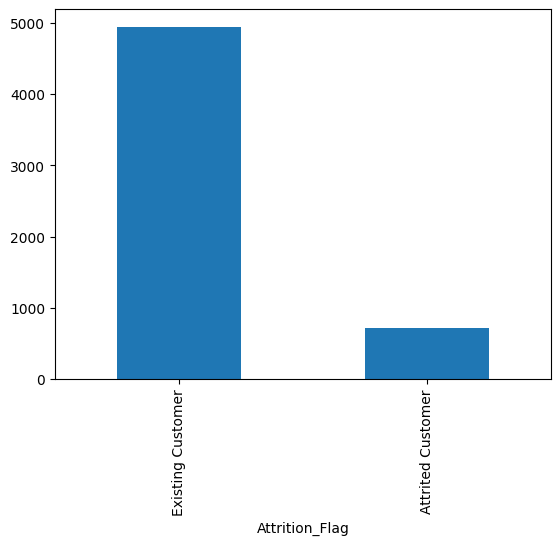

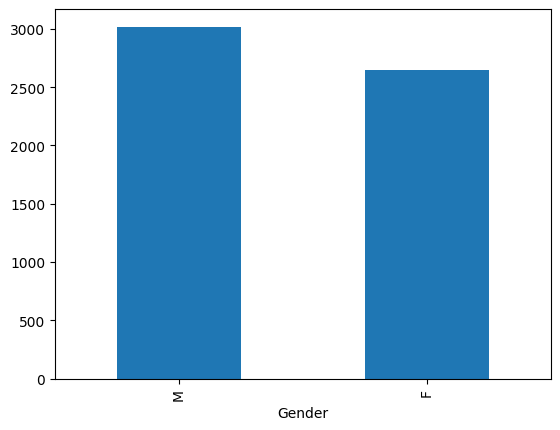

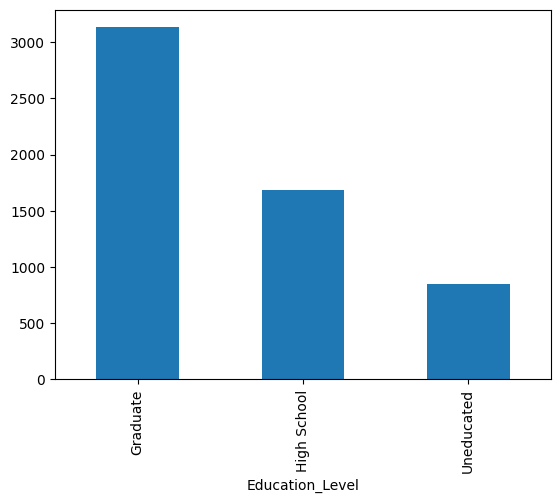

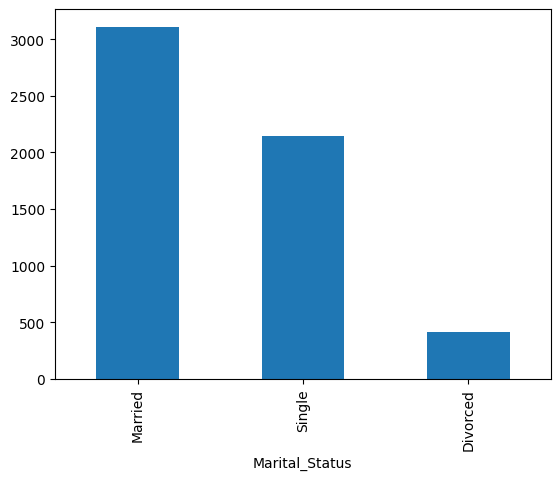

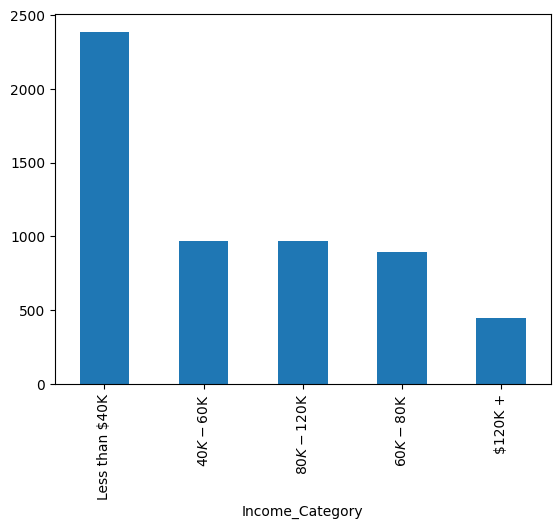

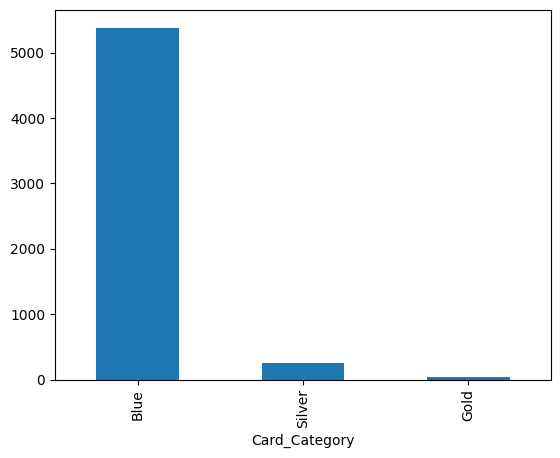

In [ ]:
df_cleaned_categorical = df_cleaned.select_dtypes(include=object)
for col in df_cleaned_categorical.columns:
    df_cleaned_categorical[col].value_counts().plot(kind='bar')
    plt.show()

In [ ]:
#Check the unique items in 'Income_Category' column
df_cleaned['Income_Category'].unique()

array(['$60K - $80K', 'Less than $40K', '$80K - $120K', '$40K - $60K',
       '$120K +'], dtype=object)

Creating histograms for each numerical features grouped by the 'Income_Category' class

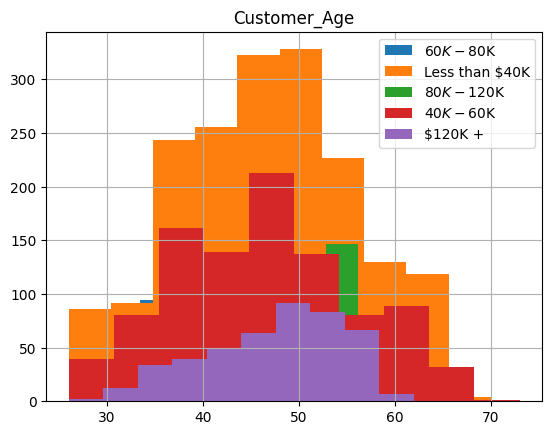

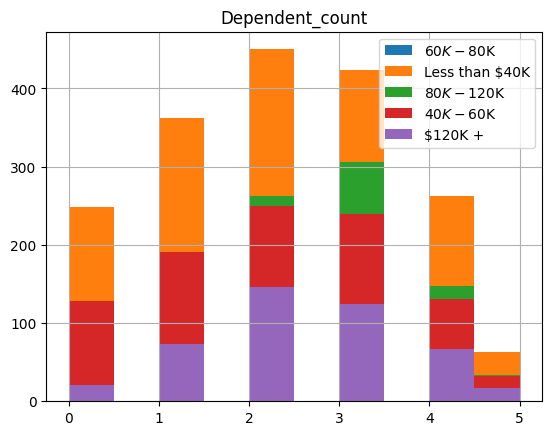

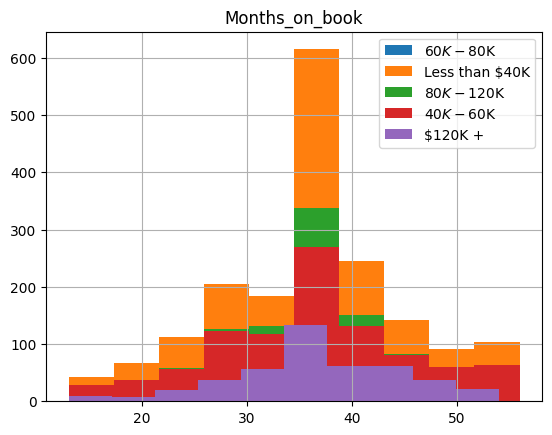

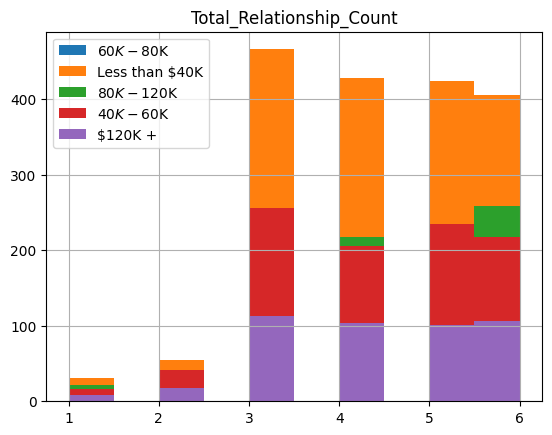

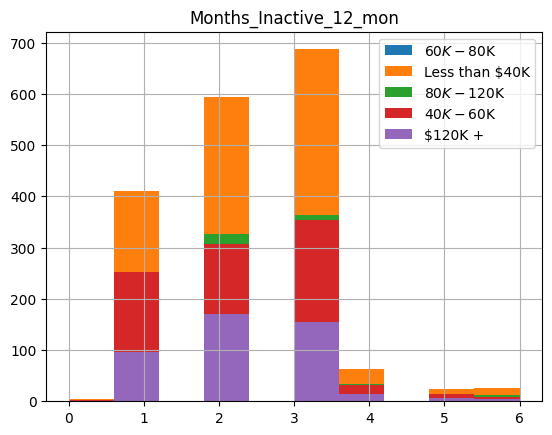

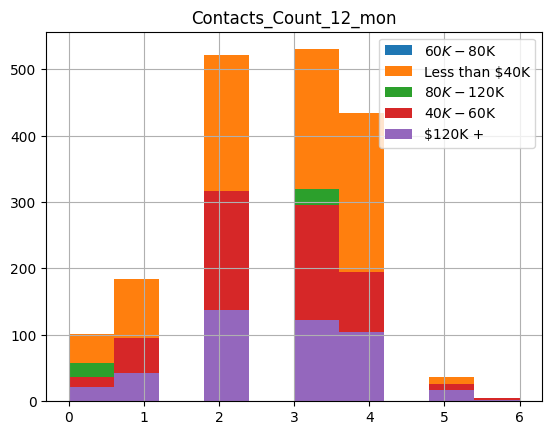

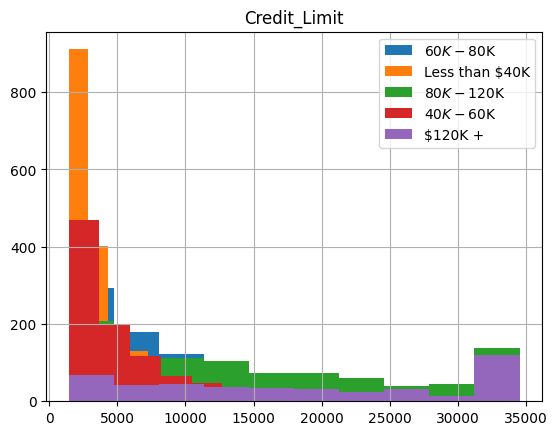

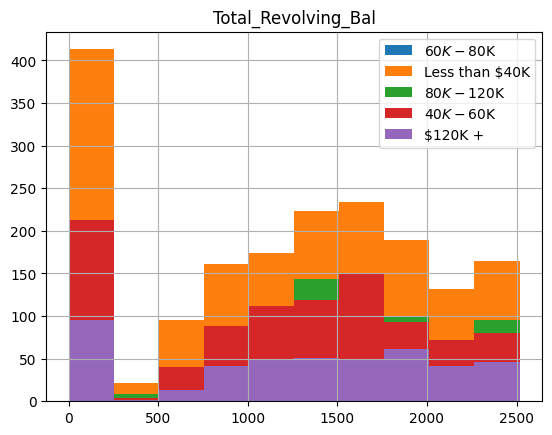

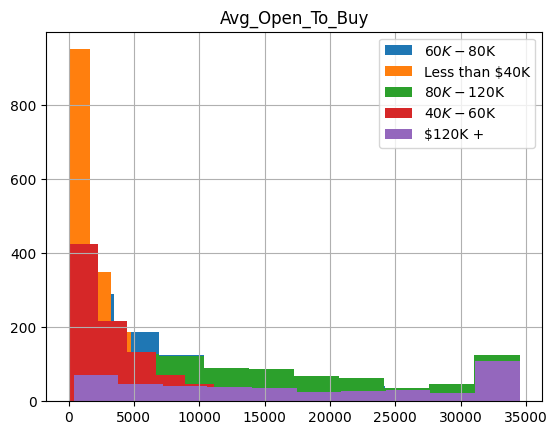

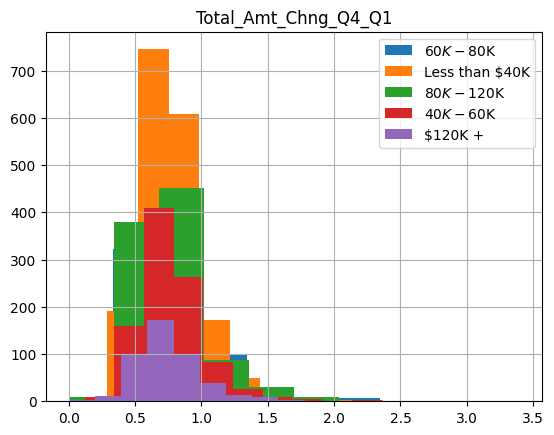

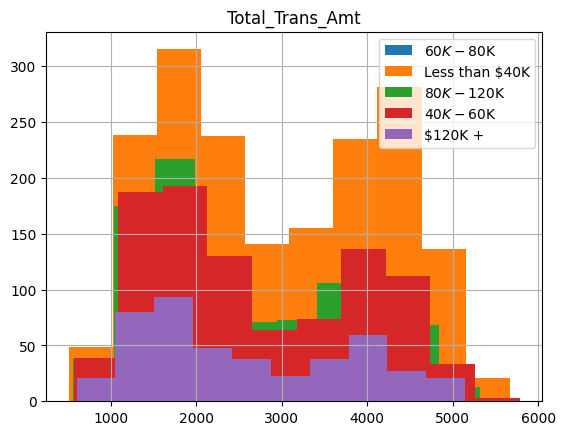

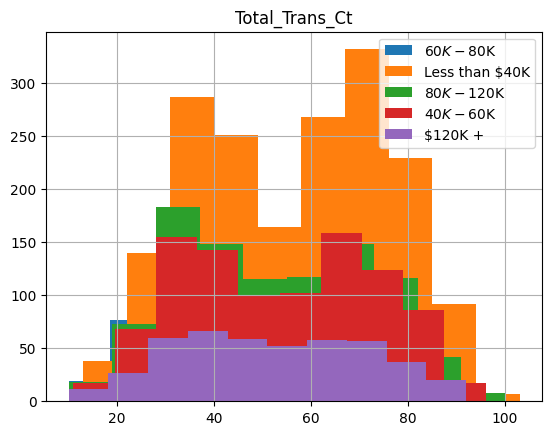

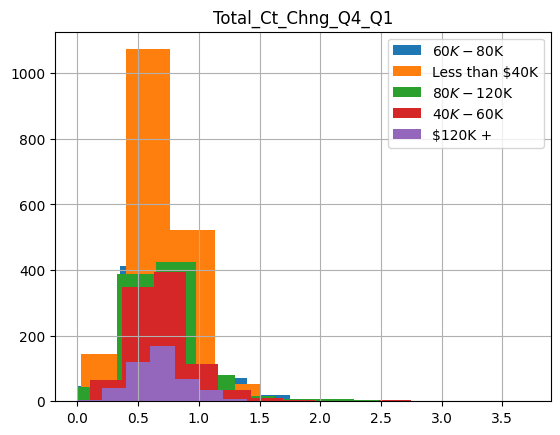

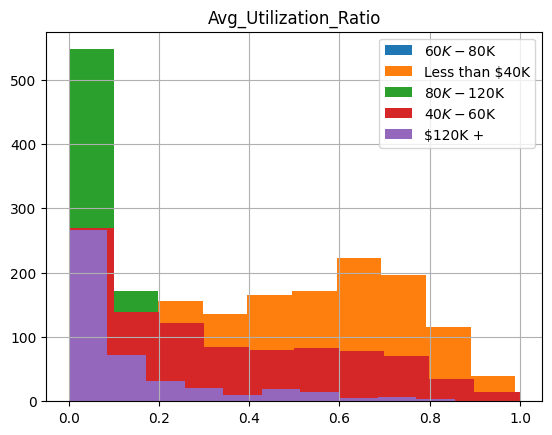

In [ ]:
#Visualization without normalization(Numerical)
for col in df_cleaned.select_dtypes(include=np.number):
    df_cleaned.loc[df['Income_Category'] == '$60K - $80K'][col].hist(label = '$60K - $80K')
    df_cleaned.loc[df['Income_Category'] == 'Less than $40K'][col].hist(label = 'Less than $40K')
    df_cleaned.loc[df['Income_Category'] == '$80K - $120K'][col].hist(label = '$80K - $120K')
    df_cleaned.loc[df['Income_Category'] == '$40K - $60K'][col].hist(label = '$40K - $60K')
    df_cleaned.loc[df['Income_Category'] == '$120K +'][col].hist(label = '$120K +')
    plt.title(col)
    plt.legend()
    plt.show()

<Axes: xlabel='Attrition_Flag', ylabel='count'>

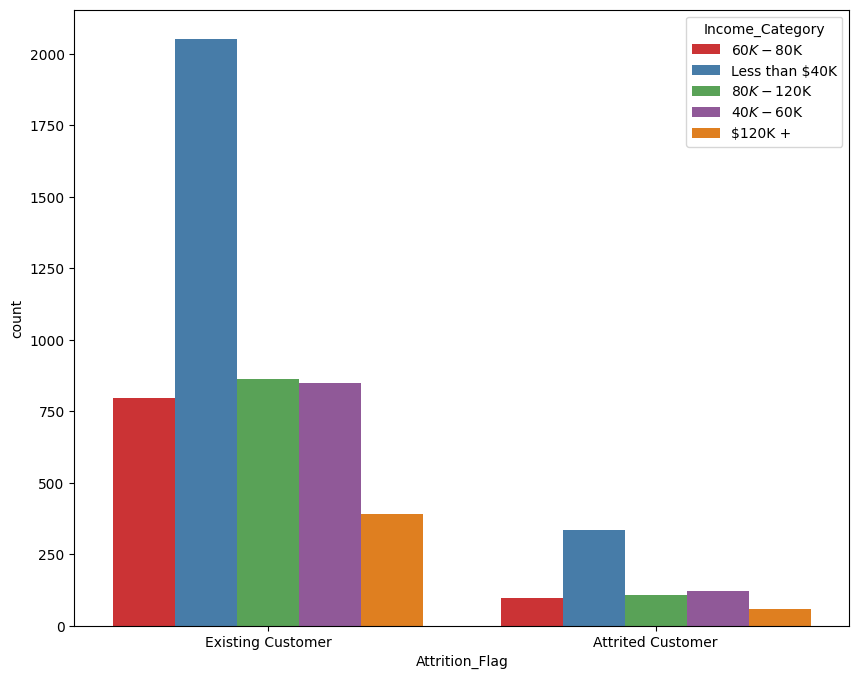

In [ ]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Attrition_Flag', hue='Income_Category', data=df_cleaned, palette='Set1')

<Axes: xlabel='Gender', ylabel='count'>

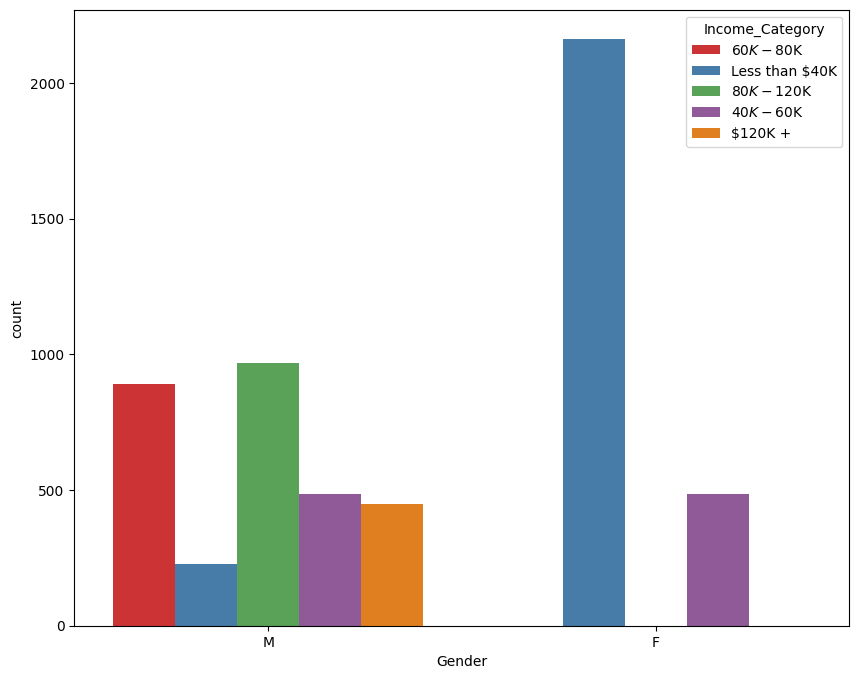

In [ ]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Gender', hue='Income_Category', data=df_cleaned, palette='Set1')

<Axes: xlabel='Education_Level', ylabel='count'>

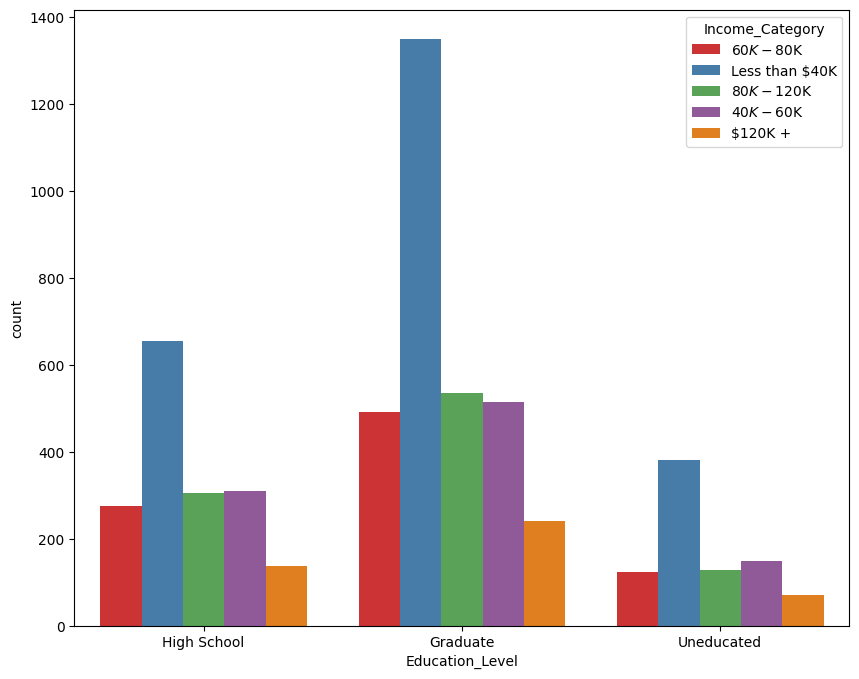

In [ ]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Education_Level', hue='Income_Category', data=df_cleaned, palette='Set1')

<Axes: xlabel='Marital_Status', ylabel='count'>

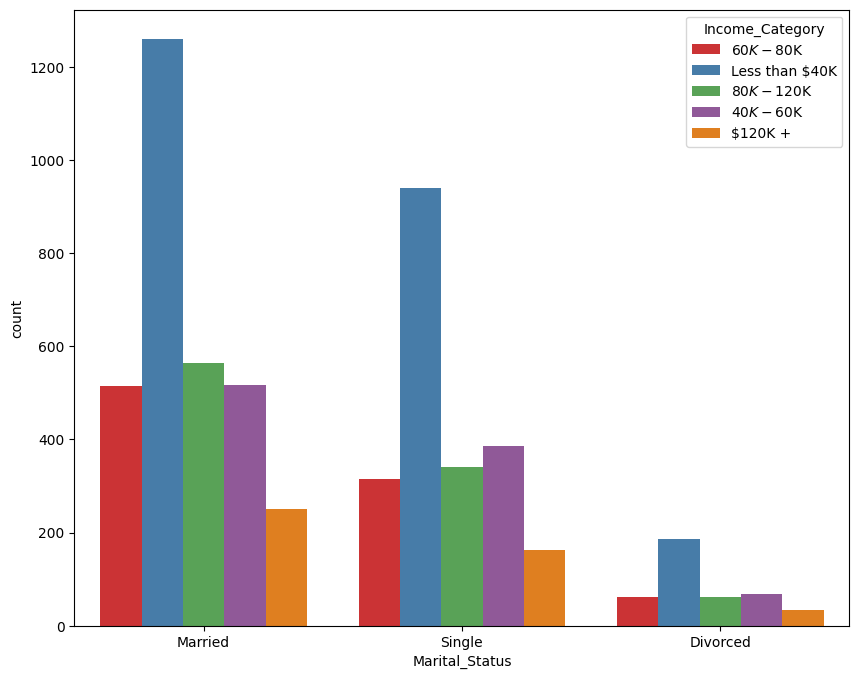

In [ ]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Marital_Status', hue='Income_Category', data=df_cleaned, palette='Set1')

<Axes: xlabel='Card_Category', ylabel='count'>

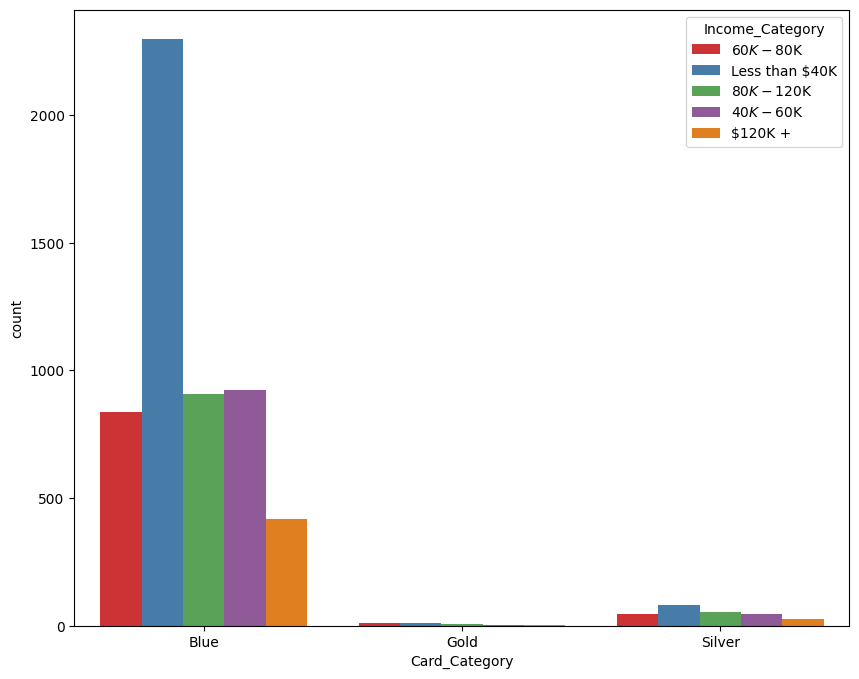

In [ ]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Card_Category', hue='Income_Category', data=df_cleaned, palette='Set1')

In [ ]:
#Get Mean,Min,Max,Standard Deviation,Percentile values
df_cleaned.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,5667.00,5667.00,5667.00,5667.00,5667.00,5667.00,5667.00,5667.00,5667.00,5667.00,5667.00,5667.00,5667.00,5667.00
mean,46.36,2.26,35.98,4.31,2.30,2.62,8866.29,1193.43,7672.87,0.78,2750.31,53.99,0.71,0.27
std,8.60,1.31,8.46,1.27,0.99,1.16,8879.27,803.33,8914.99,0.26,1217.15,19.18,0.28,0.27
min,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00,0.00,0.00
25%,40.00,1.00,31.00,3.00,2.00,2.00,2687.00,606.50,1400.50,0.61,1671.00,37.00,0.55,0.04
50%,46.00,2.00,36.00,4.00,2.00,3.00,5155.00,1311.00,3974.00,0.74,2484.00,55.00,0.68,0.17
75%,53.00,3.00,41.00,5.00,3.00,3.00,11557.50,1796.00,10356.50,0.89,3903.50,70.00,0.82,0.49
max,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,5783.00,103.00,3.71,1.00


In [ ]:
#Get number of unique values of each column
df_cleaned.nunique()

,0
Attrition_Flag,2
Customer_Age,45
Gender,2
Dependent_count,6
Education_Level,3
Marital_Status,3
Income_Category,5
Card_Category,3
Months_on_book,44
Total_Relationship_Count,6


In [ ]:
#Get Frequency
def calculate_percentage_frequencies(column):
  return column.value_counts(normalize=True) * 100
percentage_frequencies = {column: calculate_percentage_frequencies(df_cleaned[column]) for column in df_cleaned.columns}
for column, frequencies in percentage_frequencies.items():
   print(f"Percentage frequencies in column '{column}':\n{frequencies}\n")

Percentage frequencies in column 'Attrition_Flag':
Attrition_Flag
Existing Customer   87.29
Attrited Customer   12.71
Name: proportion, dtype: float64

Percentage frequencies in column 'Customer_Age':
Customer_Age
49   4.59
47   4.52
45   4.46
44   4.38
48   4.36
43   4.25
53   4.20
50   4.16
46   4.13
51   3.67
42   3.60
39   3.46
52   3.32
41   3.26
38   3.23
40   3.21
54   3.12
55   3.11
37   3.05
36   2.70
56   2.38
35   2.26
57   2.22
58   1.71
65   1.61
33   1.59
34   1.50
59   1.46
62   1.27
26   1.25
60   1.16
32   1.09
61   1.04
63   0.94
30   0.79
31   0.78
64   0.71
29   0.60
28   0.35
27   0.32
67   0.07
66   0.04
68   0.04
70   0.02
73   0.02
Name: proportion, dtype: float64

Percentage frequencies in column 'Gender':
Gender
M   53.26
F   46.74
Name: proportion, dtype: float64

Percentage frequencies in column 'Dependent_count':
Dependent_count
3   26.52
2   26.15
1   18.78
4   14.47
0   10.53
5    3.55
Name: proportion, dtype: float64

Percentage frequencies in column 'Ed

In [ ]:
#Get Percentiles
df_percentile = df_cleaned.apply(pd.to_numeric, errors='coerce')
# Calculate the 25th, 50th, and 75th percentiles for each column
percentiles = df_percentile.quantile([0.25, 0.5, 0.75])
# Transpose the result for better readability
percentiles = percentiles.transpose()
# Display the percentiles
print(percentiles)

                            0.25    0.50     0.75
Attrition_Flag               NaN     NaN      NaN
Customer_Age               40.00   46.00    53.00
Gender                       NaN     NaN      NaN
Dependent_count             1.00    2.00     3.00
Education_Level              NaN     NaN      NaN
Marital_Status               NaN     NaN      NaN
Income_Category              NaN     NaN      NaN
Card_Category                NaN     NaN      NaN
Months_on_book             31.00   36.00    41.00
Total_Relationship_Count    3.00    4.00     5.00
Months_Inactive_12_mon      2.00    2.00     3.00
Contacts_Count_12_mon       2.00    3.00     3.00
Credit_Limit             2687.00 5155.00 11557.50
Total_Revolving_Bal       606.50 1311.00  1796.00
Avg_Open_To_Buy          1400.50 3974.00 10356.50
Total_Amt_Chng_Q4_Q1        0.61    0.74     0.89
Total_Trans_Amt          1671.00 2484.00  3903.50
Total_Trans_Ct             37.00   55.00    70.00
Total_Ct_Chng_Q4_Q1         0.55    0.68     0.82


In [ ]:
#Get Medians
numerical_df = df_cleaned.select_dtypes(include=[np.number])
medians = numerical_df.median()
pd.set_option('display.float_format', '{:.2f}'.format)
print("Median values:\n", medians)

Median values:
 Customer_Age                 46.00
Dependent_count               2.00
Months_on_book               36.00
Total_Relationship_Count      4.00
Months_Inactive_12_mon        2.00
Contacts_Count_12_mon         3.00
Credit_Limit               5155.00
Total_Revolving_Bal        1311.00
Avg_Open_To_Buy            3974.00
Total_Amt_Chng_Q4_Q1          0.74
Total_Trans_Amt            2484.00
Total_Trans_Ct               55.00
Total_Ct_Chng_Q4_Q1           0.68
Avg_Utilization_Ratio         0.17
dtype: float64


In [ ]:
#Get mode of each column
df_cleaned.mode()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,49.00,M,3.00,Graduate,Married,Less than $40K,Blue,36.00,3.00,3.00,2.00,1438.30,0.00,1438.30,0.74,1468,67.00,1.00,0.00
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.79,1731,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2229,NaN,NaN,NaN


In [ ]:
#Get Variances
numerical_df1 = df_cleaned.select_dtypes(include=[np.number])
variance = numerical_df1.var()
print("Variance values:\n", variance)

Variance values:
 Customer_Age                     74.02
Dependent_count                   1.70
Months_on_book                   71.55
Total_Relationship_Count          1.62
Months_Inactive_12_mon            0.98
Contacts_Count_12_mon             1.35
Credit_Limit               78841504.94
Total_Revolving_Bal          645337.46
Avg_Open_To_Buy            79477055.96
Total_Amt_Chng_Q4_Q1              0.07
Total_Trans_Amt             1481465.07
Total_Trans_Ct                  367.86
Total_Ct_Chng_Q4_Q1               0.08
Avg_Utilization_Ratio             0.07
dtype: float64


In [ ]:
#Get Skewness values
numerical_df2 = df_cleaned.select_dtypes(include=[np.number])
skewness = numerical_df2.skew()
print("Skewness values:\n", skewness)

Skewness values:
 Customer_Age               -0.01
Dependent_count            -0.00
Months_on_book             -0.07
Total_Relationship_Count   -0.22
Months_Inactive_12_mon      0.64
Contacts_Count_12_mon      -0.25
Credit_Limit                1.60
Total_Revolving_Bal        -0.21
Avg_Open_To_Buy             1.59
Total_Amt_Chng_Q4_Q1        1.76
Total_Trans_Amt             0.26
Total_Trans_Ct             -0.00
Total_Ct_Chng_Q4_Q1         2.30
Avg_Utilization_Ratio       0.75
dtype: float64


In [ ]:
#Get Kurtosis values
numerical_df3 = df_cleaned.select_dtypes(include=[np.number])
kurtosis_values = numerical_df3.kurtosis()
print("Kurtosis values:\n", kurtosis_values)

Kurtosis values:
 Customer_Age               -0.42
Dependent_count            -0.72
Months_on_book              0.23
Total_Relationship_Count   -0.79
Months_Inactive_12_mon      1.24
Contacts_Count_12_mon      -0.20
Credit_Limit                1.66
Total_Revolving_Bal        -1.08
Avg_Open_To_Buy             1.64
Total_Amt_Chng_Q4_Q1        7.92
Total_Trans_Amt            -1.26
Total_Trans_Ct             -1.08
Total_Ct_Chng_Q4_Q1        14.15
Avg_Utilization_Ratio      -0.72
dtype: float64


Encode categorical variables

In [ ]:
label_encoder = preprocessing.LabelEncoder()

for col in list(df_cleaned.select_dtypes(include = object).columns):
    df_cleaned[col] = label_encoder.fit_transform(df_cleaned[col])

df_cleaned

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,1,45,1,3,1,1,2,0,39,5,1,3,12691.00,777,11914.00,1.33,1144,42,1.62,0.06
1,1,49,0,5,0,2,4,0,44,6,1,2,8256.00,864,7392.00,1.54,1291,33,3.71,0.10
2,1,51,1,3,0,1,3,0,36,4,1,0,3418.00,0,3418.00,2.59,1887,20,2.33,0.00
3,1,40,0,4,1,1,4,0,34,3,4,1,3313.00,2517,796.00,1.41,1171,20,2.33,0.76
4,1,40,1,3,2,1,2,0,21,5,1,0,4716.00,0,4716.00,2.17,816,28,2.50,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5665,1,49,0,3,1,1,4,0,36,3,1,3,4476.00,1492,2984.00,0.93,4603,87,0.71,0.33
5666,1,44,0,3,1,0,4,0,38,5,3,2,2002.00,1448,554.00,0.73,3406,62,0.63,0.72
5667,1,40,1,4,1,1,3,0,21,3,2,3,11502.00,2066,9436.00,0.89,4786,85,1.12,0.18
5668,0,44,1,4,0,1,0,0,39,4,3,2,7924.00,2517,5407.00,0.66,2393,37,0.68,0.32


Display the correlation between each columns

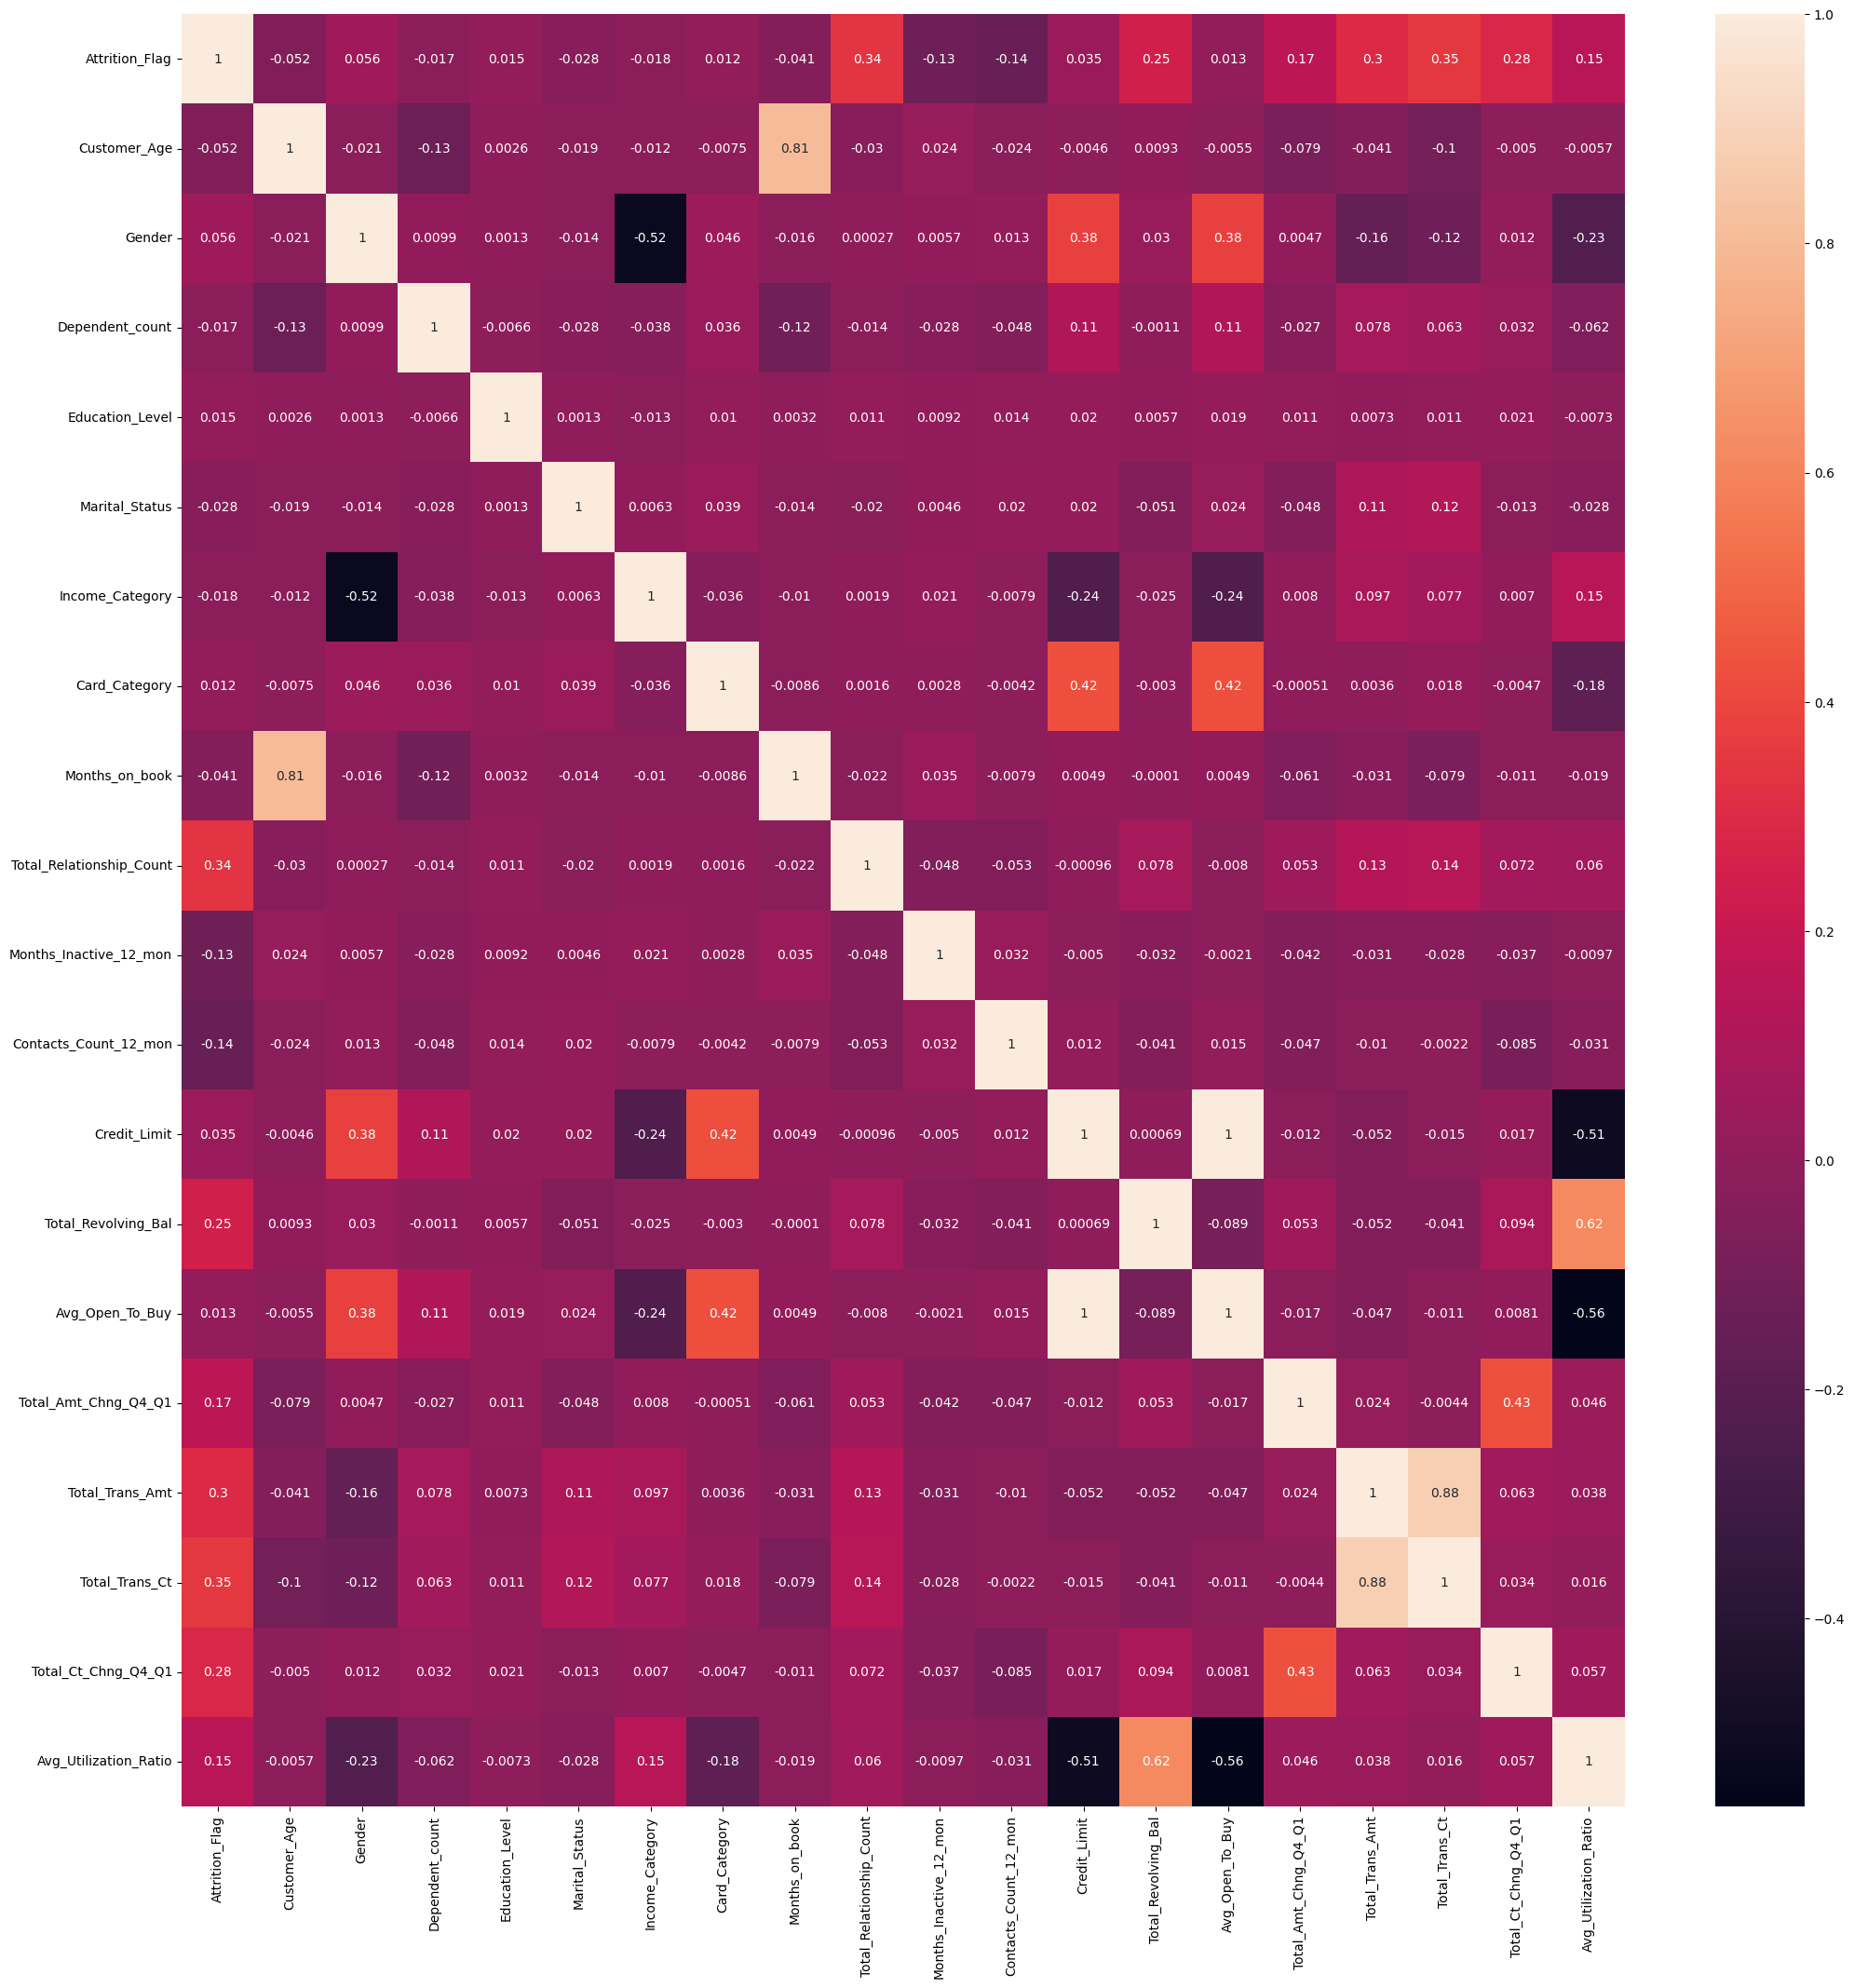

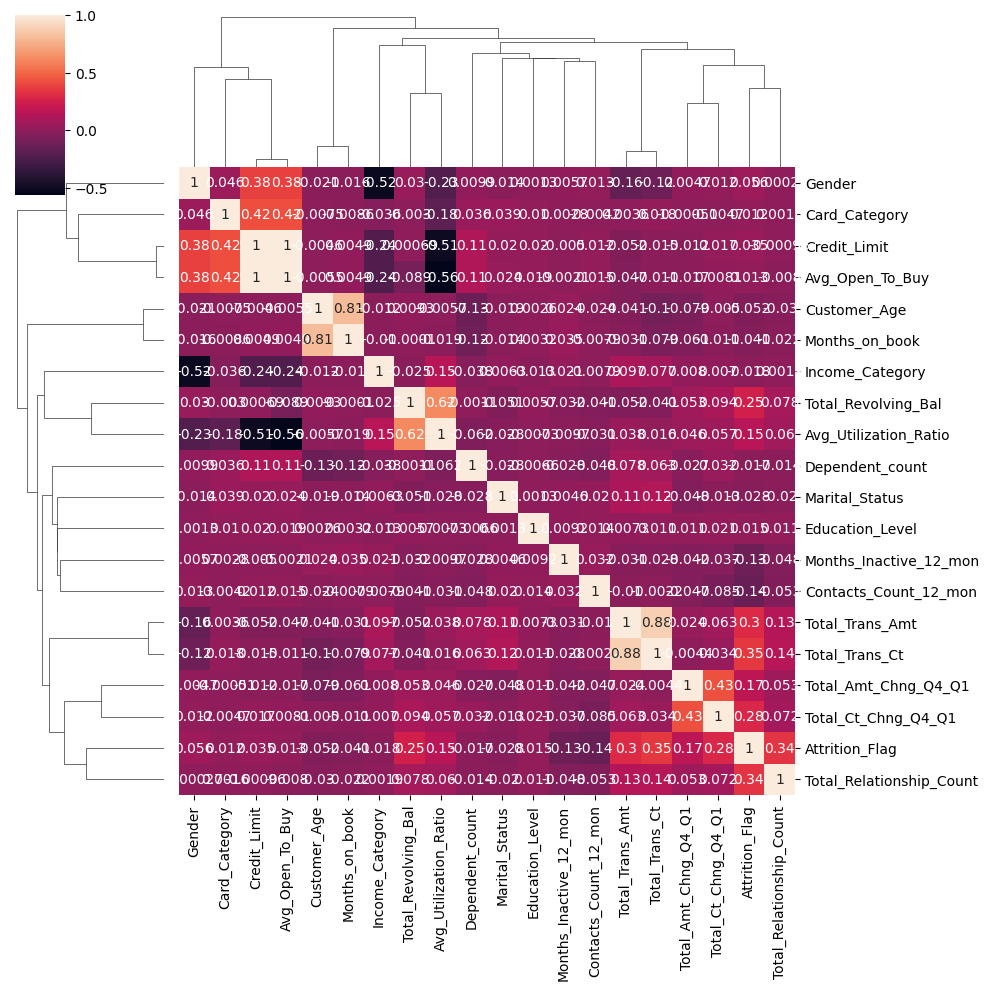

In [ ]:
# calculate the correlations
correlations = df_cleaned.corr()
fig, ax = plt.subplots(figsize=(25,25))         # Sample figsize in inches
# plot the heatmap
sns.heatmap(correlations, xticklabels=correlations.columns, yticklabels=correlations.columns, annot=True)

# plot the clustermap
sns.clustermap(correlations, xticklabels=correlations.columns, yticklabels=correlations.columns, annot=True)

plt.show()

# 4.0 Model Selection

Model choose:

Support Vector Machines (SVM)

Random Forest Classification

Random Forest Regression

# 5.0 Model Training and Evaluation

### 5.1 Support Vector Machines (SVM)

5.1.1 model training

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('/content/Credit Card Customers_cleaned.csv')

# Define the target variable y
y = data['Income_Category']

# Drop unnecessary columns
columns_to_drop = ['CLIENTNUM', 'Income_Category',
                   'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                   'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
data = data.drop(columns=columns_to_drop, axis=1)

# Identify categorical columns
categorical_columns = data.select_dtypes(include=['object', 'category']).columns

# Apply OneHotEncoder to categorical columns
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_categorical = encoder.fit_transform(data[categorical_columns])
encoded_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out(categorical_columns))

# Concat encoded categorical columns with the numerical columns
data = pd.concat([data.drop(categorical_columns, axis=1), encoded_df], axis=1)

# Assign features (X)
X = data

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create the SVM model
svm_model = SVC(random_state=42)

# Create a pipeline with scaling and SVM
pipeline = make_pipeline(StandardScaler(), svm_model)

# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)

# Evaluate the model on the testing set
y_pred_initial = pipeline.predict(X_test)
initial_accuracy = accuracy_score(y_test, y_pred_initial) * 100
print("Initial Training Accuracy: {:.2f}%".format(initial_accuracy))

Initial Training Accuracy: 58.08%


5.1.2 cross-validation

In [ ]:
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=10)
accuracy = cv_scores.mean() * 100
print("Cross Validation Accuracy: {:.2f}%".format(accuracy))

Cross Validation Accuracy: 57.92%


5.1.3 hyperparameter tuning with grid search

In [ ]:
param_grid = {
    'svc__C': [0.1, 1, 10],  # Regularization parameter for SVC
    'svc__kernel': ['linear', 'rbf', 'poly'],  # Kernel type for SVC
    'svc__gamma': ['scale', 'auto'],  # Kernel coefficient for SVC
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

# Print the best parameters
print("Best Parameters found by GridSearchCV:", grid_search.best_params_)

Best Parameters found by GridSearchCV: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}


5.1.4 model evaluate

In [ ]:
# Train the model with the best parameters
best_svm_model = grid_search.best_estimator_

#make predictions on the testing
y_pred = best_svm_model.predict(X_test)

accuracy_best = accuracy_score(y_test, y_pred) * 100
print("Best model accuracy: {:.2f}%".format(accuracy_best))

Best model accuracy: 58.38%


5.1.5 bar chart

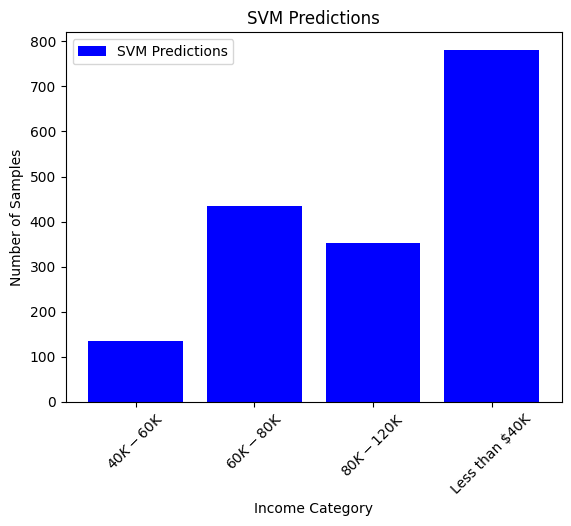

In [ ]:
unique_labels_svm = np.unique(y_pred)
class_counts_svm = [sum(y_pred == label) for label in unique_labels_svm]

plt.bar(unique_labels_svm, class_counts_svm, color='blue', label='SVM Predictions')
plt.xlabel('Income Category')
plt.xticks(rotation=45)
plt.ylabel('Number of Samples')
plt.title('SVM Predictions')
plt.legend()
plt.show()

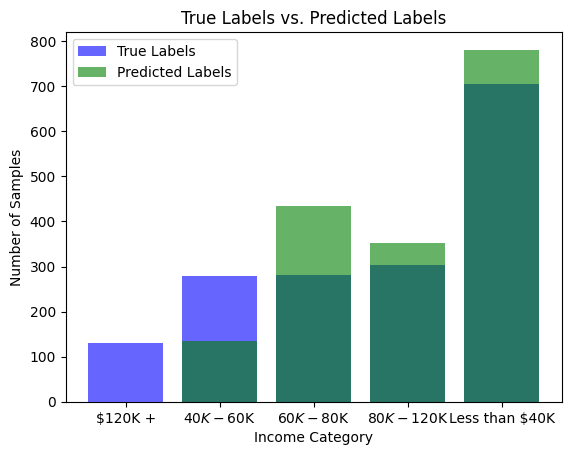

In [ ]:
unique_labels_true = np.unique(y_test)
unique_labels_pred = np.unique(y_pred)

plt.bar(unique_labels_true, [sum(y_test == label) for label in unique_labels_true], color='blue', alpha=0.6, label='True Labels')
plt.bar(unique_labels_pred, [sum(y_pred == label) for label in unique_labels_pred], color='green', alpha=0.6, label='Predicted Labels')
plt.xlabel('Income Category')
plt.ylabel('Number of Samples')
plt.title('True Labels vs. Predicted Labels')
plt.legend()
plt.show()

## 5.2 Random Forest

5.2.1 model training

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

data = pd.read_csv("/content/Credit Card Customers_cleaned.csv")

label_encoder = LabelEncoder()
data['Income_Category'] = label_encoder.fit_transform(data['Income_Category'])
data['Education_Level'] = label_encoder.fit_transform(data['Education_Level'])

column_to_drop = data[['Income_Category', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1','Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']]
X = data.drop(columns=column_to_drop, axis=1)
y = data['Income_Category']

categorical_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', X.columns.difference(categorical_cols)),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.205, random_state=5000)

rf = RandomForestClassifier(n_estimators=300, random_state=5000)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf) * 100
print(f'Random Forest Test Accuracy: {accuracy_rf:.2f}%')

print(classification_report(y_test, y_pred_rf))


Random Forest Test Accuracy: 62.85%
              precision    recall  f1-score   support

           0       0.50      0.16      0.24        87
           1       0.35      0.12      0.18       191
           2       0.41      0.64      0.50       172
           3       0.46      0.46      0.46       199
           4       0.82      0.96      0.88       514

    accuracy                           0.63      1163
   macro avg       0.51      0.47      0.45      1163
weighted avg       0.60      0.63      0.59      1163



5.2.2 cross validation

In [ ]:
cv_scores = cross_val_score(rf, X_train, y_train, cv=10)
cv_accuracy = cv_scores.mean() * 100
print(f'Cross-Validation Accuracy: {cv_accuracy:.2f}%')

Cross-Validation Accuracy: 59.53%


5.2.2 hyperparameter tuning

In [ ]:
param_grid_rf = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [10, 20, 30]
}

grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5)

grid_search_rf.fit(X_train, y_train)

print(f'Best parameter: {grid_search_rf.best_params_}')
print(f'Best score: {grid_search_rf.best_score_}')

Best parameter: {'max_depth': 10, 'n_estimators': 300}
Best score: 0.602614980644812


5.2.3 model evaluate

In [ ]:
best_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf) * 100
print(f'Best model accuracy: {accuracy_best_rf:.2f}%')
print(classification_report(y_test, y_pred_best_rf))

Best model accuracy: 61.65%
              precision    recall  f1-score   support

           0       0.47      0.10      0.17        87
           1       0.34      0.07      0.11       191
           2       0.37      0.65      0.47       172
           3       0.46      0.47      0.47       199
           4       0.82      0.95      0.88       514

    accuracy                           0.62      1163
   macro avg       0.49      0.45      0.42      1163
weighted avg       0.59      0.62      0.57      1163



5.2.4 chart

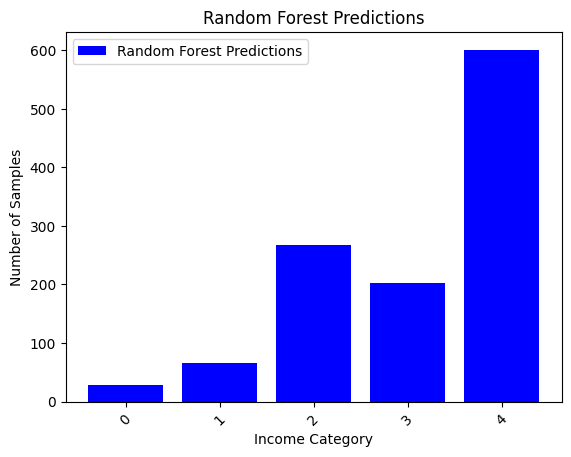

In [ ]:
unique_labels_rf = np.unique(y_pred_rf)

class_counts_rf = [sum(y_pred_rf == label) for label in unique_labels_rf]

plt.bar(unique_labels_rf, class_counts_rf, color='blue', label='Random Forest Predictions')
plt.xlabel('Income Category')
plt.xticks(rotation=45)
plt.ylabel('Number of Samples')
plt.title('Random Forest Predictions')
plt.legend()

plt.show()

# 5.3 Random Forest

5.3.1 Setup and Installation

In [ ]:
!pip install --upgrade scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             r2_score)

# Random Forest
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

import joblib

print("Imports done, and Google Drive mounted successfully!")


Mounted at /content/drive
Imports done, and Google Drive mounted successfully!


5.3.2 Data Loading and Exploration

In [ ]:
file_path = '/content/drive/MyDrive/Credit Card Customers_cleaned_minmax.csv'

# Load the CSV file
data = pd.read_csv('/content/drive/My Drive/dataset/Credit Card Customers_cleaned_minmax.csv')
print("Dataset loaded successfully!\n")

# Quick preview
print(data.head())
print("\nData Info:")
print(data.info())


Dataset loaded successfully!

      Attrition_Flag  Customer_Age Gender  Dependent_count Education_Level  \
0  Existing Customer      0.404255      M              0.6     High School   
1  Existing Customer      0.489362      F              1.0        Graduate   
2  Existing Customer      0.531915      M              0.6        Graduate   
3  Existing Customer      0.297872      F              0.8     High School   
4  Existing Customer      0.297872      M              0.6      Uneducated   

  Marital_Status Income_Category Card_Category  Months_on_book  \
0        Married     $60K - $80K          Blue        0.604651   
1         Single  Less than $40K          Blue        0.720930   
2        Married    $80K - $120K          Blue        0.534884   
3        Married  Less than $40K          Blue        0.488372   
4        Married     $60K - $80K          Blue        0.186047   

   Total_Relationship_Count  Months_Inactive_12_mon  Contacts_Count_12_mon  \
0                       0.

5.3.3 Data Preparation

In [ ]:
# Classification features
X = data[['Credit_Limit', 'Total_Revolving_Bal', 'Total_Trans_Amt']]  # Adjust if necessary
y_class = data['Income_Category']  # Classification target

# Encode classification target if it's categorical
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_class_encoded = label_encoder.fit_transform(y_class)

# Regression target
if 'Avg_Utilization_Ratio' not in data.columns:
    raise ValueError("Column 'Avg_Utilization_Ratio' not found in data. Check your column name.")
y_reg = data['Avg_Utilization_Ratio'].astype(float)


In [ ]:
from sklearn.model_selection import train_test_split

# Make an array of all row indices in your dataset
all_indices = np.arange(len(data))

# Split *indices* (not the data itself) into train/test
train_idxs, test_idxs = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42
)


In [ ]:
# Slice X and the encoded classification target by row indices
X_train_c = X.iloc[train_idxs]
X_test_c  = X.iloc[test_idxs]

y_train_c = y_class_encoded[train_idxs]
y_test_c  = y_class_encoded[test_idxs]

print("Classification splits done!")
print("X_train_c shape:", X_train_c.shape)
print("X_test_c shape:", X_test_c.shape)
print("y_train_c shape:", y_train_c.shape)
print("y_test_c shape:", y_test_c.shape)


Classification splits done!
X_train_c shape: (4533, 3)
X_test_c shape: (1134, 3)
y_train_c shape: (4533,)
y_test_c shape: (1134,)


In [ ]:
# Regression slides
# y_reg is a Pandas Series, so use .iloc[] with the same row indices
y_train_r = y_reg.iloc[train_idxs]
y_test_r  = y_reg.iloc[test_idxs]

print("\nRegression splits done!")
print("y_train_r shape:", y_train_r.shape)
print("y_test_r shape:", y_test_r.shape)



Regression splits done!
y_train_r shape: (4533,)
y_test_r shape: (1134,)


5.3.4 Model Training

Classification:


Classification Accuracy: 0.47

Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.07      0.11        99
           1       0.43      0.02      0.03       186
           2       0.23      0.08      0.12       173
           3       0.31      0.40      0.35       186
           4       0.54      0.88      0.67       490

    accuracy                           0.47      1134
   macro avg       0.35      0.29      0.26      1134
weighted avg       0.41      0.47      0.38      1134



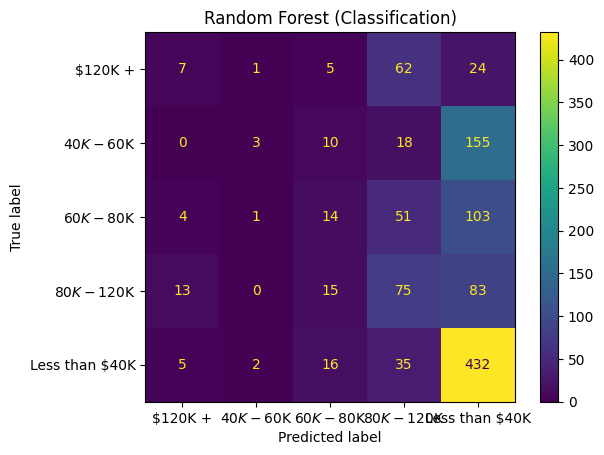

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_classifier.fit(X_train_c, y_train_c)

y_pred_c = rf_classifier.predict(X_test_c)
accuracy_c = accuracy_score(y_test_c, y_pred_c)

print(f"\nClassification Accuracy: {accuracy_c:.2f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))

cm_c = confusion_matrix(y_test_c, y_pred_c)
ConfusionMatrixDisplay(confusion_matrix=cm_c, display_labels=label_encoder.classes_).plot()
plt.title("Random Forest (Classification)")
plt.show()


Evaluation for Regression:

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf_regressor = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_regressor.fit(X_train_c, y_train_r)  # Same features, different target

y_pred_r = rf_regressor.predict(X_test_c)
r2 = r2_score(y_test_r, y_pred_r)

print(f"\nRegression R² Score: {r2:.2f}")



Regression R² Score: 1.00


# 6.0 Final Deliverable

6.1 Table


| Model         | Accuracy | Cross-validation | Best model accuracy  | R-squared score|
|----------------|---------------|---------------|-------|--|
| SVM | 58.08%    | 57.92%    | 59.33% | - |
| Random Forest Classification   |62.85%    | 59.53%    | 61.65% | - |
| Random Forest Regression | -         | - | -| 1.0 |
